In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## myeloid

In [120]:
# 1. 데이터 로드
matrix_path = "/data/project/arpa_h/raw_data/split/9_genes_original/raw_myeloid_filtered_matrix.csv"
df = pd.read_csv(matrix_path, index_col=0)  # Unnamed: 0 → gene names
#df

# 원하는 순서의 리스트
gene_order = ["VSIG4", "LYVE1", "CLEC5A", "CX3CR1", "FN1", "IL11", "NRAP", "SDC1", "SCG5"]
df = df.loc[gene_order]
df

,Che_2021-SRR14710630-AAAGATGAGAGGTAGA,Che_2021-SRR14710630-AAAGCAAGTTCAGCGC,Che_2021-SRR14710630-AACCATGTCGTACCGG,Che_2021-SRR14710630-AACGTTGGTCTCCATC,Che_2021-SRR14710630-AAGACCTAGCCCAGCT,Che_2021-SRR14710630-AAGACCTGTGTGAAAT,Che_2021-SRR14710630-AAGCCGCAGTAGCCGA,Che_2021-SRR14710630-ACACCGGAGGTAGCTG,Che_2021-SRR14710630-ACAGCTACATGGAATA,Che_2021-SRR14710630-ACGATACGTCAGAGGT,...,Zheng_2022-GSM4904246-TGGCCAGCAAGTCTAC,Zheng_2022-GSM4904246-TGGGAAGAGCTGTCTA,Zheng_2022-GSM4904246-TGTATTCCACGAAACG,Zheng_2022-GSM4904246-TTAGTTCCATCGATGT,Zheng_2022-GSM4904246-TTAGTTCTCCACGCAG,Zheng_2022-GSM4904246-TTCGAAGGTTCGCTAA,Zheng_2022-GSM4904246-TTCTCAACAAGTAATG,Zheng_2022-GSM4904246-TTGAACGTCATGTCTT,Zheng_2022-GSM4904246-TTTACTGTCAGAAATG,Zheng_2022-GSM4904246-TTTGGTTGTCCAGTAT
VSIG4,0.827065,0.876204,0.0,0.386227,0.224762,0.590233,0.699881,0.904102,0.000000,0.0,...,0.0,0.0,1.402957,0.829983,0.0,0.950386,0.0,1.211248,0.0,0.0
LYVE1,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,1.078382,0.0,0.000000,0.0,1.743155,0.0,0.0
CLEC5A,0.000000,0.876204,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
CX3CR1,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
FN1,0.675466,1.649677,0.0,1.458598,0.408160,0.000000,1.309063,0.488505,1.554232,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
IL11,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
NRAP,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
SDC1,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0
SCG5,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0


In [121]:
# Median 발현값
median_expr = df.median(axis=1, skipna=True)
median_expr

VSIG4     0.0
LYVE1     0.0
CLEC5A    0.0
CX3CR1    0.0
FN1       0.0
IL11      0.0
NRAP      0.0
SDC1      0.0
SCG5      0.0
dtype: float64

In [122]:
# mean 발현값
mean_expr = df.mean(axis=1, skipna=True)
print(mean_expr)
formatted_mean_expr = mean_expr.apply(lambda x: f"{x:.2e}")
print(formatted_mean_expr)

VSIG4     0.176155
LYVE1     0.029445
CLEC5A    0.063117
CX3CR1    0.081875
FN1       0.099975
IL11      0.000188
NRAP      0.000010
SDC1      0.001883
SCG5      0.001326
dtype: float64
VSIG4     1.76e-01
LYVE1     2.94e-02
CLEC5A    6.31e-02
CX3CR1    8.19e-02
FN1       1.00e-01
IL11      1.88e-04
NRAP      9.81e-06
SDC1      1.88e-03
SCG5      1.33e-03
dtype: object


In [123]:
# NaN을 0으로 치지 않고, 실제 0인 셀만 세기
zero_only = (df == 0)
zero_ratio = zero_only.sum(axis=1) / df.shape[1]
zero_ratio

VSIG4     0.760101
LYVE1     0.968541
CLEC5A    0.884161
CX3CR1    0.878005
FN1       0.905643
IL11      0.998781
NRAP      0.999917
SDC1      0.992378
SCG5      0.996612
dtype: float64

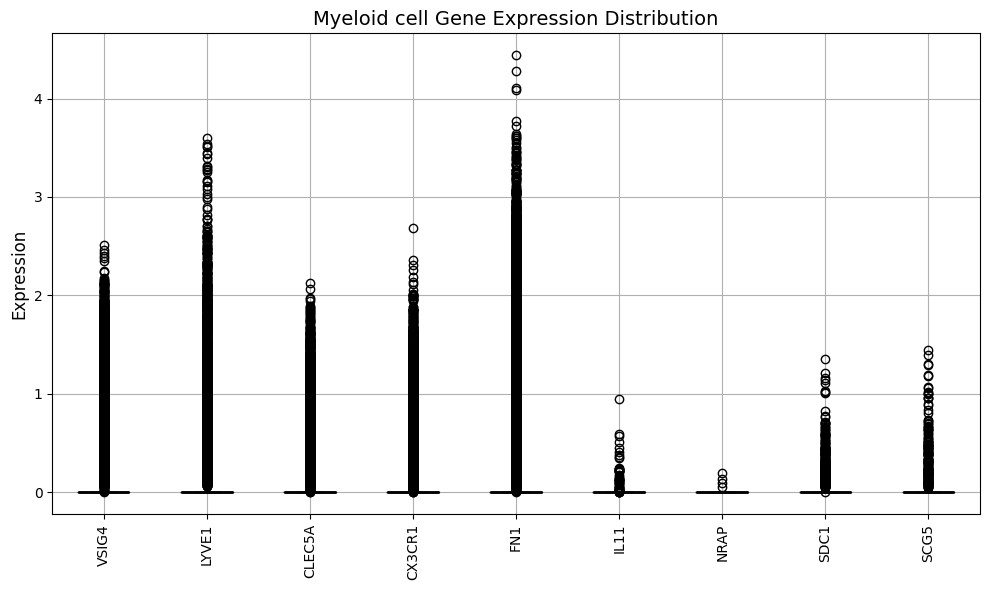

In [124]:
# 유전자별 발현 박스플롯 (검은색 박스/중앙선)
plt.figure(figsize=(10, 6))
ax = df.T.boxplot(
    vert=True,
    rot=90,
    boxprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markeredgecolor='black', markerfacecolor='none')
)
plt.title("Myeloid cell Gene Expression Distribution", fontsize=14)
plt.ylabel("Expression", fontsize=12)
plt.tight_layout()
plt.show()

In [125]:
# 2. 메타데이터 로드
meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_myeloid_cell_consensus.csv"
meta = pd.read_csv(meta_path, index_col="cell_name")  
meta
# index: cell_name, 컬럼 중 'Group_born'에 MSI/MSS 정보가 들어 있어요

,Group_born,Batch,Group
cell_name,,,
Che_2021-SRR14710630-AAAGATGAGAGGTAGA,MSS,Myeloid cell,MSS_high
Che_2021-SRR14710630-AAAGCAAGTTCAGCGC,MSS,Myeloid cell,MSS_high
Che_2021-SRR14710630-AACCATGTCGTACCGG,MSS,Myeloid cell,MSS_high
Che_2021-SRR14710630-AACGTTGGTCTCCATC,MSS,Myeloid cell,MSS_high
Che_2021-SRR14710630-AAGACCTAGCCCAGCT,MSS,Myeloid cell,MSS_high
...,...,...,...
Zheng_2022-GSM4904246-TTCGAAGGTTCGCTAA,MSS,Myeloid cell,MSS_high
Zheng_2022-GSM4904246-TTCTCAACAAGTAATG,MSS,Myeloid cell,MSS_high
Zheng_2022-GSM4904246-TTGAACGTCATGTCTT,MSS,Myeloid cell,MSS_high


In [126]:
# 2) 전체 셀 개수
total_cells = meta.shape[0]

# 3) MSI vs MSS 셀 개수
group_counts = meta["Group_born"].value_counts()

print(f"전체 셀 개수: {total_cells}")
print("Group_born별 셀 개수:")
print(group_counts)

전체 셀 개수: 48412
Group_born별 셀 개수:
Group_born
MSS    27846
MSI    20566
Name: count, dtype: int64


In [127]:
# 2) 그룹별 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 발현된 셀 개수 계산
expr_counts = pd.DataFrame({
    "msi_count":   (df[msi_cells] > 0).sum(axis=1),
    "mss_count":   (df[mss_cells] > 0).sum(axis=1)
})

# 4) 두 그룹 합 대비 비율 (각 유전자별)
expr_props = expr_counts.div(expr_counts.sum(axis=1), axis=0)
expr_props.columns = ["msi_probability", "mss_prbability"]
expr_props

,msi_probability,mss_prbability
VSIG4,0.071810,0.928190
LYVE1,0.013132,0.986868
CLEC5A,0.168509,0.831491
CX3CR1,0.675415,0.324585
FN1,0.080342,0.919658
IL11,0.084746,0.915254
NRAP,0.000000,1.000000
SDC1,0.035230,0.964770
SCG5,0.298780,0.701220


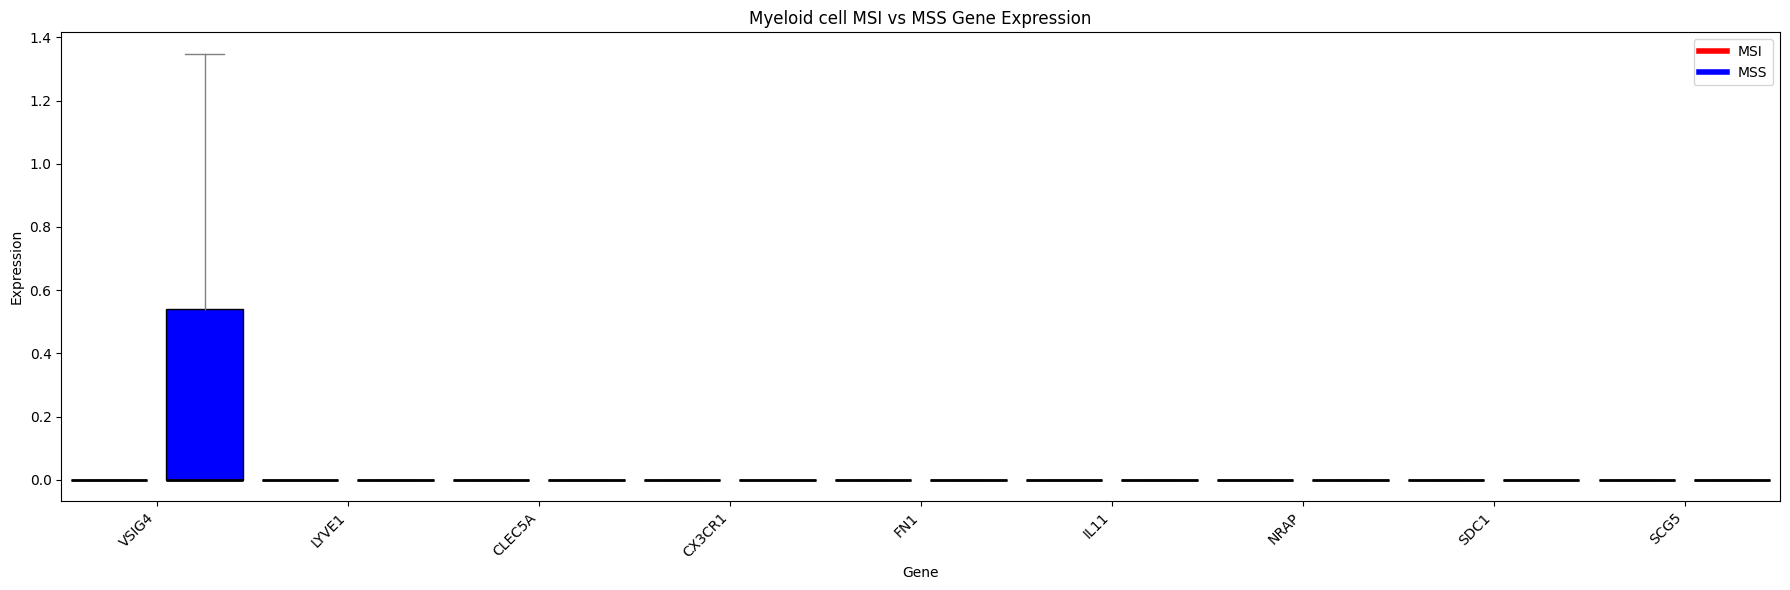

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



# 2) MSI/MSS 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 유전자 리스트 (인덱스)
genes = df.index.tolist()

# 4) 데이터와 위치 설정
data = []
positions = []
labels = []  # for gene names at center

for i, gene in enumerate(genes):
    # 각 gene마다 MSI 데이터, MSS 데이터 추가
    data.append(df.loc[gene, msi_cells].dropna())
    data.append(df.loc[gene, mss_cells].dropna())
    # 위치: 2*i+1, 2*i+2
    positions.extend([2*i+1, 2*i+2])
    # gene label 위치 중앙(2*i+1.5)
    labels.append((2*i+1 + 2*i+2)/2)

# 5) 박스플롯
# plt.figure(figsize=(2*len(genes), 6))
# box = plt.boxplot(data,
#                   positions=positions,
#                   widths=0.8,
#                   patch_artist=True,
#                   showfliers=False)
# 5) 박스플롯 그리기 (medianprops 추가)
plt.figure(figsize=(2*len(genes), 6))
box = plt.boxplot(
    data,
    positions=positions,
    widths=0.8,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)

# 6) 색상 지정: MSI 빨강, MSS 파랑
for idx, patch in enumerate(box['boxes']):
    if idx % 2 == 0:      # 짝수 인덱스 → MSI
        patch.set_facecolor('red')
    else:                 # 홀수 인덱스 → MSS
        patch.set_facecolor('blue')

# x축 눈금: gene 이름을 중앙에
plt.xticks(labels, genes, rotation=45, ha='right')

# 8) 범례 추가
red_patch = plt.Line2D([0], [0], color='red', lw=4)
blue_patch = plt.Line2D([0], [0], color='blue', lw=4)
plt.legend([red_patch, blue_patch], ['MSI', 'MSS'], loc='upper right')

plt.xlabel("Gene")
plt.ylabel("Expression")
plt.title("Myeloid cell MSI vs MSS Gene Expression")
        

plt.tight_layout()
plt.show()

## random10

In [129]:
# 1. 데이터 로드
matrix_path = "/data/project/arpa_h/raw_data/split/9_genes_original/raw_random10_filtered_matrix.csv"
df = pd.read_csv(matrix_path, index_col=0)  # Unnamed: 0 → gene names
#df

# 원하는 순서의 리스트
gene_order = ["VSIG4", "LYVE1", "CLEC5A", "CX3CR1", "FN1", "IL11", "NRAP", "SDC1", "SCG5"]
df = df.loc[gene_order]
df

,Borras_2023_SMC5-SMC057T-GCTCCTACACGAAGCA,Borras_2023_SMC5-SMC057T-TACCTTACACGTCAGC,Borras_2023_SMC5-SMC071T-GAGTCCGCAGTCGATT,Borras_2023_SMC5-SMC071T-GTGCTTCAGCAGACTG,Borras_2023_SMC5-SMC083T-TGTTCCGGTGGCCCTA,Borras_2023_SMC5-SMC136T-CCCATACCAGGGATTG,Che_2021-SRR14710630-CGGACACCATGTTCCC,Chen_2024-GSM7558371-CCGTTCAGTAGGCATG,Chen_2024-GSM7558472-CATTATCGTTGAGTTC,Chen_2024-GSM7558472-CTGTGCTTCTCATTCA,...,deVries_2023_LUMC-HTO8-AACACGTAGCCACTAT,deVries_2023_LUMC-HTO8-ACACCAAAGATGTAAC,deVries_2023_LUMC-HTO8-ACGCCGATCAAGCCTA,deVries_2023_LUMC-HTO8-AGCTCCTCAAAGTGCG,deVries_2023_LUMC-HTO8-CCATTCGCAGGCAGTA,deVries_2023_LUMC-HTO9-CGACCTTTCTCAACTT,deVries_2023_LUMC-HTO8-CGGAGCTGTGAAAGAG,deVries_2023_LUMC-HTO8-CTCGTCACATAGGATA,deVries_2023_LUMC-HTO8-GCCAAATCAGAGCCAA,deVries_2023_LUMC-HTO8-GGAACTTGTAAGAGAG
VSIG4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
LYVE1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CLEC5A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CX3CR1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
FN1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
IL11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NRAP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SDC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.574025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SCG5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [130]:
# Median 발현값
median_expr = df.median(axis=1, skipna=True)
median_expr

VSIG4     0.000000
LYVE1     0.000000
CLEC5A    0.000000
CX3CR1    0.000000
FN1       0.000000
IL11      0.000000
NRAP      0.000000
SDC1      0.106627
SCG5      0.000000
dtype: float64

In [131]:
# mean 발현값
mean_expr = df.mean(axis=1, skipna=True)
print(mean_expr)
formatted_mean_expr = mean_expr.apply(lambda x: f"{x:.2e}")
print(formatted_mean_expr)

VSIG4     0.000895
LYVE1     0.005985
CLEC5A    0.000651
CX3CR1    0.000328
FN1       0.189791
IL11      0.003658
NRAP      0.000166
SDC1      0.162472
SCG5      0.017669
dtype: float64
VSIG4     8.95e-04
LYVE1     5.98e-03
CLEC5A    6.51e-04
CX3CR1    3.28e-04
FN1       1.90e-01
IL11      3.66e-03
NRAP      1.66e-04
SDC1      1.62e-01
SCG5      1.77e-02
dtype: object


In [132]:
# NaN을 0으로 치지 않고, 실제 0인 셀만 세기
zero_only = (df == 0)
zero_ratio = zero_only.sum(axis=1) / df.shape[1]
zero_ratio

VSIG4     0.993891
LYVE1     0.995329
CLEC5A    0.994610
CX3CR1    0.998922
FN1       0.839382
IL11      0.973410
NRAP      0.997844
SDC1      0.336328
SCG5      0.911247
dtype: float64

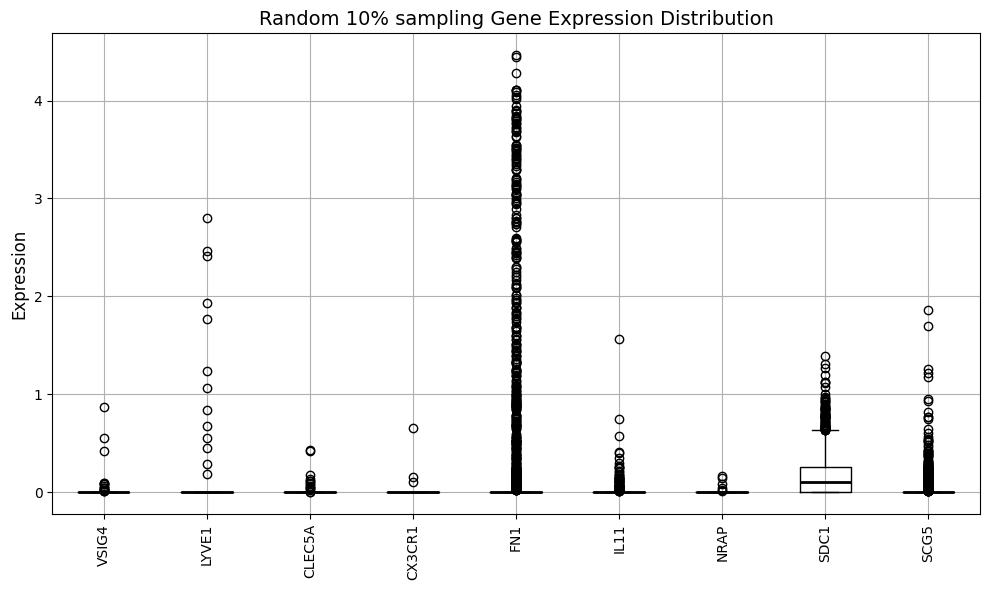

In [133]:
# 유전자별 발현 박스플롯 (검은색 박스/중앙선)
plt.figure(figsize=(10, 6))
ax = df.T.boxplot(
    vert=True,
    rot=90,
    boxprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markeredgecolor='black', markerfacecolor='none')
)
plt.title("Random 10% sampling Gene Expression Distribution", fontsize=14)
plt.ylabel("Expression", fontsize=12)
plt.tight_layout()
plt.show()

In [134]:
# 2. 메타데이터 로드
meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_random10_consensus.csv"
meta = pd.read_csv(meta_path, index_col="cell_name")  
meta
# index: cell_name, 컬럼 중 'Group_born'에 MSI/MSS 정보가 들어 있어요

,Group_born,Batch,Group
cell_name,,,
Borras_2023_SMC5-SMC057T-GCTCCTACACGAAGCA,MSI,T cell,MSI_high
Borras_2023_SMC5-SMC057T-TACCTTACACGTCAGC,MSI,T cell,MSI_high
Borras_2023_SMC5-SMC071T-GAGTCCGCAGTCGATT,MSI,T cell,MSI_high
Borras_2023_SMC5-SMC071T-GTGCTTCAGCAGACTG,MSI,T cell,MSI_high
Borras_2023_SMC5-SMC083T-TGTTCCGGTGGCCCTA,MSI,T cell,MSI_high
...,...,...,...
deVries_2023_LUMC-HTO9-CGACCTTTCTCAACTT,MSI,T cell,MSI_high
deVries_2023_LUMC-HTO8-CGGAGCTGTGAAAGAG,MSI,T cell,MSI_high
deVries_2023_LUMC-HTO8-CTCGTCACATAGGATA,MSI,T cell,MSI_high


In [135]:
# 2) 전체 셀 개수
total_cells = meta.shape[0]

# 3) MSI vs MSS 셀 개수
group_counts = meta["Group_born"].value_counts()

print(f"전체 셀 개수: {total_cells}")
print("Group_born별 셀 개수:")
print(group_counts)

전체 셀 개수: 2783
Group_born별 셀 개수:
Group_born
MSS    2113
MSI     670
Name: count, dtype: int64


In [136]:
# 2) 그룹별 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 발현된 셀 개수 계산
expr_counts = pd.DataFrame({
    "msi_count":   (df[msi_cells] > 0).sum(axis=1),
    "mss_count":   (df[mss_cells] > 0).sum(axis=1)
})

# 4) 두 그룹 합 대비 비율 (각 유전자별)
expr_props = expr_counts.div(expr_counts.sum(axis=1), axis=0)
expr_props.columns = ["msi_probability", "mss_prbability"]
expr_props

,msi_probability,mss_prbability
VSIG4,0.176471,0.823529
LYVE1,0.846154,0.153846
CLEC5A,0.533333,0.466667
CX3CR1,0.000000,1.000000
FN1,0.158837,0.841163
IL11,0.108108,0.891892
NRAP,0.666667,0.333333
SDC1,0.208988,0.791012
SCG5,0.275304,0.724696


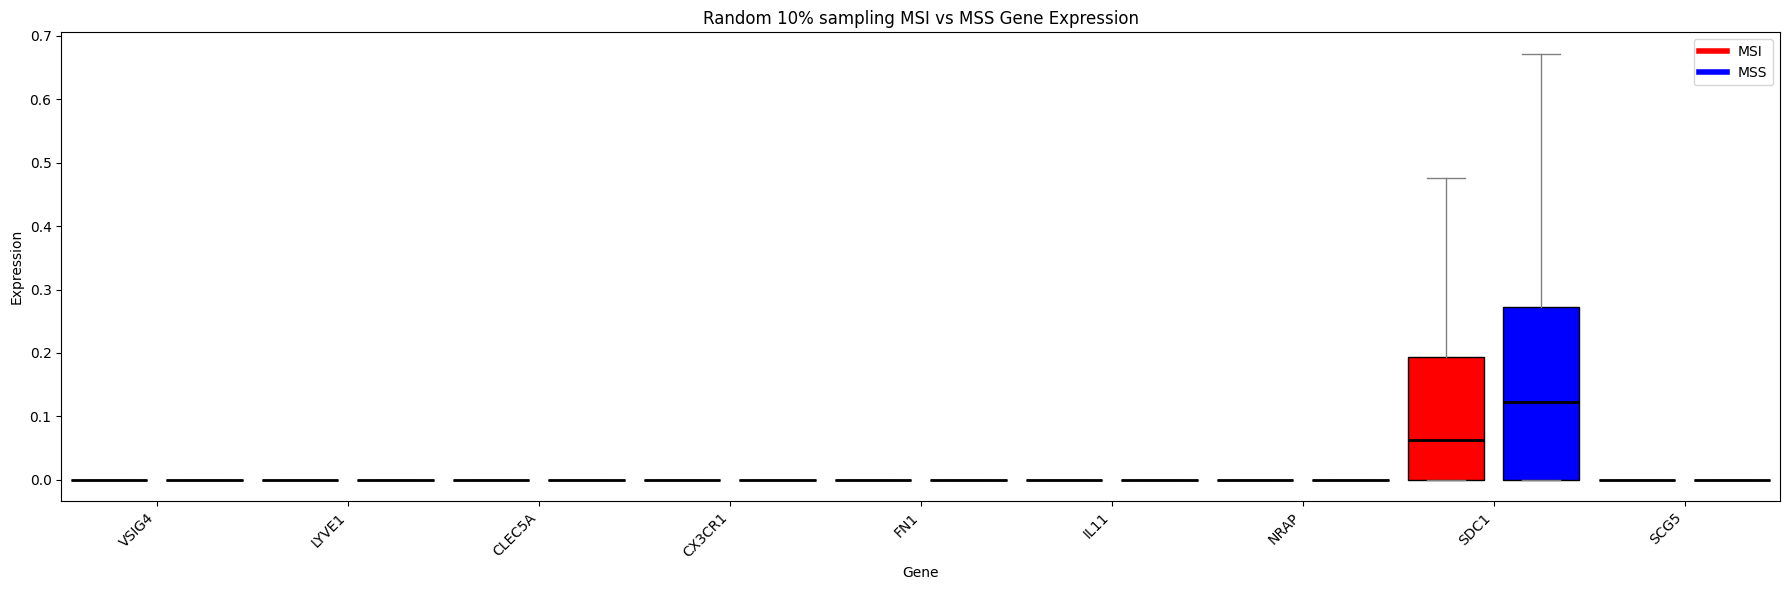

In [137]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 2) MSI/MSS 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 유전자 리스트 (인덱스)
genes = df.index.tolist()

# 4) 데이터와 위치 설정
data = []
positions = []
labels = []  # for gene names at center

for i, gene in enumerate(genes):
    # 각 gene마다 MSI 데이터, MSS 데이터 추가
    data.append(df.loc[gene, msi_cells].dropna())
    data.append(df.loc[gene, mss_cells].dropna())
    # 위치: 2*i+1, 2*i+2
    positions.extend([2*i+1, 2*i+2])
    # gene label 위치 중앙(2*i+1.5)
    labels.append((2*i+1 + 2*i+2)/2)

# 5) 박스플롯
# plt.figure(figsize=(2*len(genes), 6))
# box = plt.boxplot(data,
#                   positions=positions,
#                   widths=0.8,
#                   patch_artist=True,
#                   showfliers=False)
# 5) 박스플롯 그리기 (medianprops 추가)
plt.figure(figsize=(2*len(genes), 6))
box = plt.boxplot(
    data,
    positions=positions,
    widths=0.8,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)

# 6) 색상 지정: MSI 빨강, MSS 파랑
for idx, patch in enumerate(box['boxes']):
    if idx % 2 == 0:      # 짝수 인덱스 → MSI
        patch.set_facecolor('red')
    else:                 # 홀수 인덱스 → MSS
        patch.set_facecolor('blue')

# x축 눈금: gene 이름을 중앙에
plt.xticks(labels, genes, rotation=45, ha='right')

# 8) 범례 추가
red_patch = plt.Line2D([0], [0], color='red', lw=4)
blue_patch = plt.Line2D([0], [0], color='blue', lw=4)
plt.legend([red_patch, blue_patch], ['MSI', 'MSS'], loc='upper right')

plt.xlabel("Gene")
plt.ylabel("Expression")
plt.title("Random 10% sampling MSI vs MSS Gene Expression")
        

plt.tight_layout()
plt.show()

## Epithelial

In [138]:
# 1. 데이터 로드
matrix_path = "/data/project/arpa_h/raw_data/split/9_genes_original/raw_Epithelial_filtered_matrix.csv"
df = pd.read_csv(matrix_path, index_col=0)  # Unnamed: 0 → gene names
#df

# 원하는 순서의 리스트
gene_order = ["VSIG4", "LYVE1", "CLEC5A", "CX3CR1", "FN1", "IL11", "NRAP", "SDC1", "SCG5"]
df = df.loc[gene_order]
df

,Che_2021-SRR14710620-GCAAACTCATGCGCAC,Che_2021-SRR14710616-GTAGGCCAGTCCTCCT,Chen_2024-GSM7558333-CACACCTGTATATCCG,Chen_2024-GSM7558333-CAGTCCTTCTGGCGAC,Chen_2024-GSM7558333-CTCCTAGGTCATCGGC,Chen_2024-GSM7558333-GCAGCCATCGATAGAA,Chen_2024-GSM7558333-GGATTACTCTTAACCT,Chen_2024-GSM7558333-GTTAAGCGTATCACCA,Chen_2024-GSM7558333-TACCTTAAGACAAGCC,Chen_2024-GSM7558334-CAGGTGCCAGACTCGC,...,Zheng_2022-GSM4904243-GCATGCGGTACGAAAT,Zheng_2022-GSM4904243-GCATGTAAGAGACTTA,Zheng_2022-GSM4904243-GCTGCAGCAGCGTCCA,Zheng_2022-GSM4904243-GGATGTTCAGCTGCTG,Zheng_2022-GSM4904243-TGCACCTAGTCTCGGC,Zheng_2022-GSM4904243-TTAGGACTCTTCGGTC,Zheng_2022-GSM4904246-ACGGGCTAGTGAACGC,Zheng_2022-GSM4904246-AGCGTATGTGGCCCTA,Zheng_2022-GSM4904246-CATTATCTCAGCTCTC,Zheng_2022-GSM4904246-CGCTTCAGTATAGGGC
VSIG4,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.000000,0.00000,0.00000,0.000000,0.0,0.0,0.000000,0.000000
LYVE1,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.000000,0.00000,0.00000,0.000000,0.0,0.0,0.000000,0.000000
CLEC5A,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.000000,0.00000,0.00000,0.000000,0.0,0.0,0.000000,0.000000
CX3CR1,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.000000,0.00000,0.00000,0.000000,0.0,0.0,0.000000,0.000000
FN1,0.0,0.0,1.425324,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.158136,0.00000,0.000000,0.00000,0.00000,0.000000,0.0,0.0,0.433452,0.158041
IL11,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.000000,0.00000,0.00000,0.000000,0.0,0.0,0.000000,0.000000
NRAP,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.00000,0.000000,0.00000,0.00000,0.000000,0.0,0.0,0.000000,0.000000
SDC1,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.158136,0.38438,0.273071,0.09092,0.27856,0.328507,0.0,0.0,0.185205,0.414519
SCG5,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.414739,0.00000,0.000000,0.00000,0.00000,0.000000,0.0,0.0,0.000000,0.000000


In [139]:
# Median 발현값
median_expr = df.median(axis=1, skipna=True)
median_expr

VSIG4     0.0
LYVE1     0.0
CLEC5A    0.0
CX3CR1    0.0
FN1       0.0
IL11      0.0
NRAP      0.0
SDC1      0.0
SCG5      0.0
dtype: float64

In [140]:
# mean 발현값
mean_expr = df.mean(axis=1, skipna=True)
print(mean_expr)
formatted_mean_expr = mean_expr.apply(lambda x: f"{x:.2e}")
print(formatted_mean_expr)

VSIG4     0.000389
LYVE1     0.000281
CLEC5A    0.000027
CX3CR1    0.000213
FN1       0.037252
IL11      0.000663
NRAP      0.001071
SDC1      0.095194
SCG5      0.003517
dtype: float64
VSIG4     3.89e-04
LYVE1     2.81e-04
CLEC5A    2.65e-05
CX3CR1    2.13e-04
FN1       3.73e-02
IL11      6.63e-04
NRAP      1.07e-03
SDC1      9.52e-02
SCG5      3.52e-03
dtype: object


In [141]:
# NaN을 0으로 치지 않고, 실제 0인 셀만 세기
zero_only = (df == 0)
zero_ratio = zero_only.sum(axis=1) / df.shape[1]
print(zero_ratio)

VSIG4     0.999190
LYVE1     0.999595
CLEC5A    0.999797
CX3CR1    0.999392
FN1       0.937411
IL11      0.998177
NRAP      0.996152
SDC1      0.779218
SCG5      0.987442
dtype: float64


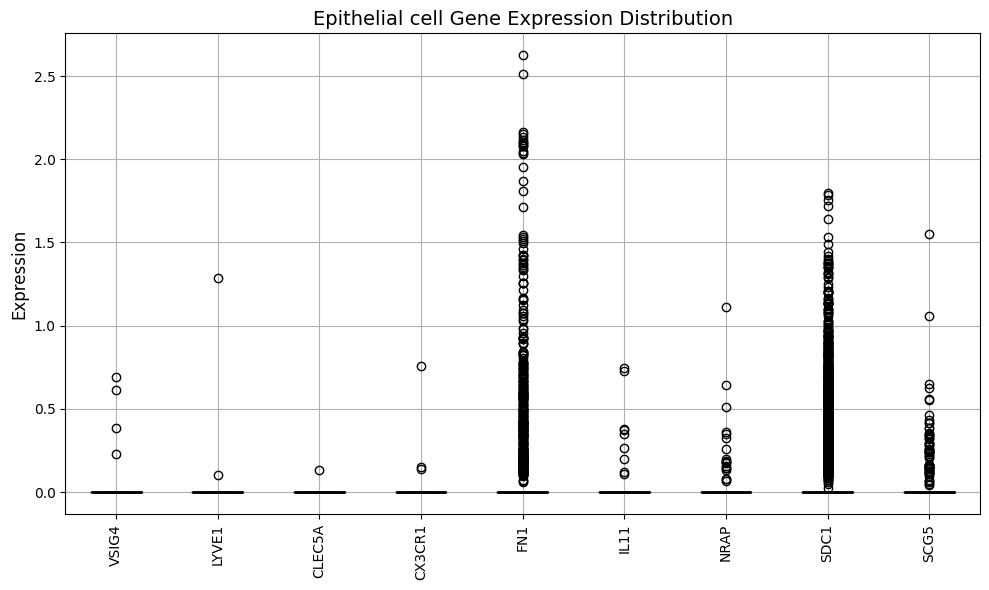

In [142]:
# 유전자별 발현 박스플롯 (검은색 박스/중앙선)
plt.figure(figsize=(10, 6))
ax = df.T.boxplot(
    vert=True,
    rot=90,
    boxprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markeredgecolor='black', markerfacecolor='none')
)
plt.title("Epithelial cell Gene Expression Distribution", fontsize=14)
plt.ylabel("Expression", fontsize=12)
plt.tight_layout()
plt.show()

In [143]:
# 2. 메타데이터 로드
meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_Epithelial_consensus.csv"
meta = pd.read_csv(meta_path, index_col="Cell")  
meta
# index: cell_name, 컬럼 중 'Group_born'에 MSI/MSS 정보가 들어 있어요

,Group_born,Batch,Group
Cell,,,
Che_2021-SRR14710620-GCAAACTCATGCGCAC,MSS,Epithelial cell,MSS_high
Che_2021-SRR14710616-GTAGGCCAGTCCTCCT,MSS,Epithelial cell,MSS_high
Chen_2024-GSM7558333-CACACCTGTATATCCG,MSS,Epithelial cell,MSI_high
Chen_2024-GSM7558333-CAGTCCTTCTGGCGAC,MSS,Epithelial cell,MSI_high
Chen_2024-GSM7558333-CTCCTAGGTCATCGGC,MSS,Epithelial cell,MSI_high
...,...,...,...
Zheng_2022-GSM4904243-TTAGGACTCTTCGGTC,MSS,Epithelial cell,MSS_high
Zheng_2022-GSM4904246-ACGGGCTAGTGAACGC,MSS,Epithelial cell,MSS_high
Zheng_2022-GSM4904246-AGCGTATGTGGCCCTA,MSS,Epithelial cell,MSS_high


In [144]:
# 2) 전체 셀 개수
total_cells = meta.shape[0]

# 3) MSI vs MSS 셀 개수
group_counts = meta["Group_born"].value_counts()

print(f"전체 셀 개수: {total_cells}")
print("Group_born별 셀 개수:")
print(group_counts)

전체 셀 개수: 4937
Group_born별 셀 개수:
Group_born
MSS    3219
MSI    1718
Name: count, dtype: int64


In [145]:
# 2) 그룹별 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 발현된 셀 개수 계산
expr_counts = pd.DataFrame({
    "msi_count":   (df[msi_cells] > 0).sum(axis=1),
    "mss_count":   (df[mss_cells] > 0).sum(axis=1)
})

# 4) 두 그룹 합 대비 비율 (각 유전자별)
expr_props = expr_counts.div(expr_counts.sum(axis=1), axis=0)
expr_props.columns = ["msi_probability", "mss_prbability"]
expr_props

,msi_probability,mss_prbability
VSIG4,0.750000,0.250000
LYVE1,0.500000,0.500000
CLEC5A,1.000000,0.000000
CX3CR1,0.333333,0.666667
FN1,0.446602,0.553398
IL11,0.222222,0.777778
NRAP,0.473684,0.526316
SDC1,0.324771,0.675229
SCG5,0.306452,0.693548


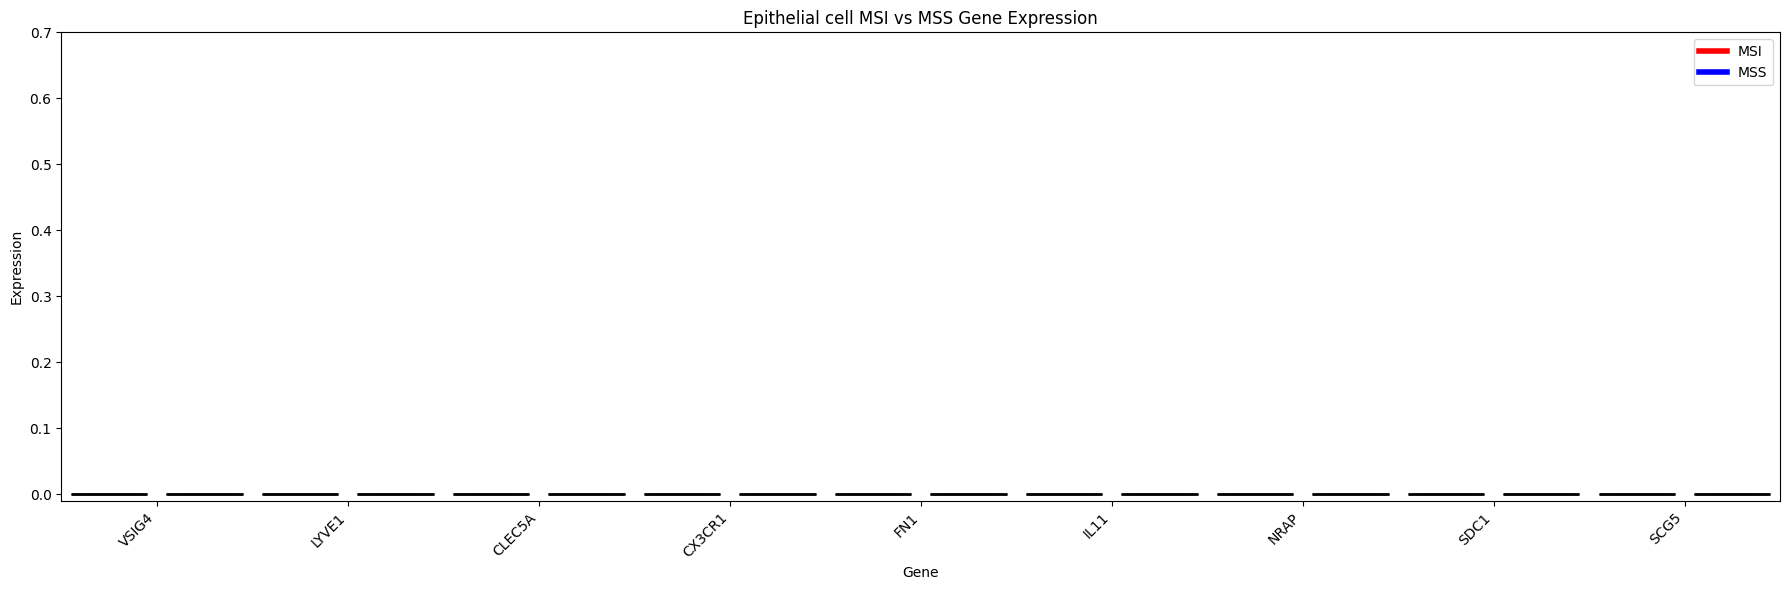

In [146]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 2) MSI/MSS 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 유전자 리스트 (인덱스)
genes = df.index.tolist()

# 4) 데이터와 위치 설정
data = []
positions = []
labels = []  # for gene names at center

for i, gene in enumerate(genes):
    # 각 gene마다 MSI 데이터, MSS 데이터 추가
    data.append(df.loc[gene, msi_cells].dropna())
    data.append(df.loc[gene, mss_cells].dropna())
    # 위치: 2*i+1, 2*i+2
    positions.extend([2*i+1, 2*i+2])
    # gene label 위치 중앙(2*i+1.5)
    labels.append((2*i+1 + 2*i+2)/2)

# 5) 박스플롯
# plt.figure(figsize=(2*len(genes), 6))
# box = plt.boxplot(data,
#                   positions=positions,
#                   widths=0.8,
#                   patch_artist=True,
#                   showfliers=False)
# 5) 박스플롯 그리기 (medianprops 추가)
plt.figure(figsize=(2*len(genes), 6))
box = plt.boxplot(
    data,
    positions=positions,
    widths=0.8,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)

# 6) 색상 지정: MSI 빨강, MSS 파랑
for idx, patch in enumerate(box['boxes']):
    if idx % 2 == 0:      # 짝수 인덱스 → MSI
        patch.set_facecolor('red')
    else:                 # 홀수 인덱스 → MSS
        patch.set_facecolor('blue')

# x축 눈금: gene 이름을 중앙에
plt.xticks(labels, genes, rotation=45, ha='right')

# 8) 범례 추가
red_patch = plt.Line2D([0], [0], color='red', lw=4)
blue_patch = plt.Line2D([0], [0], color='blue', lw=4)
plt.legend([red_patch, blue_patch], ['MSI', 'MSS'], loc='upper right')

plt.xlabel("Gene")
plt.ylabel("Expression")
plt.title("Epithelial cell MSI vs MSS Gene Expression")
        
plt.ylim(-0.01, 0.7)
plt.tight_layout()
plt.show()

## Neutrophil

In [147]:
# 1. 데이터 로드
matrix_path = "/data/project/arpa_h/raw_data/split/9_genes_original/raw_neutrophil_filtered_matrix.csv"
df = pd.read_csv(matrix_path, index_col=0)  # Unnamed: 0 → gene names
#df

# 원하는 순서의 리스트
gene_order = ["VSIG4", "LYVE1", "CLEC5A", "CX3CR1", "FN1", "IL11", "NRAP", "SDC1", "SCG5"]
df = df.loc[gene_order]
df

,Che_2021-SRR14710629-GGGATGAGTTGACGTT,Chen_2024-GSM7558371-GCAAACTGTCAGTGGA,Chen_2024-GSM7558464-GTCACGGCACAACGCC,Chen_2024-GSM7558510-TGAGCCGGTTTGTTTC,Chen_2024-GSM7558567-AAAGTAGCATGGATGG,Chen_2024-GSM7558567-AAGTCTGGTCTCTTTA,Chen_2024-GSM7558567-ACAGCTAAGCTAACAA,Chen_2024-GSM7558567-ACCAGTAAGCAGACTG,Chen_2024-GSM7558567-ACTTTCAGTACGACCC,Chen_2024-GSM7558567-AGAGTGGTCTCGAGTA,...,Wu_2022_CD45Pos-P19_Colon_T-CTACTATTCTCCACTG-1,Wu_2022_CD45Pos-P19_Colon_T-GATGGAGCACAGGATG-1,Wu_2022_CD45Pos-P19_Colon_T-TCACACCTCGTTCCCA-1,Wu_2022_CD45Pos-P19_Colon_T-TCAGGGCTCCCAAGTA-1,Wu_2022_CD45Pos-P19_Colon_T-TTGAGTGCAAGCGAGT-1,Wu_2022_CD45Pos-P19_Colon_T-TTGCATTTCCGAGAAG-1,Wu_2022_CD45Pos-P14_Liver_T-ACAGGGAAGACATCCT-1,Zheng_2022-GSM4904238-AAGGTTCAGTGGCACA,Zheng_2022-GSM4904238-TCAATCTAGCAGCGTA,Zheng_2022-GSM4904245-AACTGGTAGGCCCTCA
VSIG4,1.066302,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
LYVE1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
CLEC5A,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.581559,0.0,0.0,0.0,0.0,0.0,0.0
CX3CR1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
FN1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
IL11,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
NRAP,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
SDC1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
SCG5,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [148]:
# Median 발현값
median_expr = df.median(axis=1, skipna=True)
median_expr

VSIG4     0.0
LYVE1     0.0
CLEC5A    0.0
CX3CR1    0.0
FN1       0.0
IL11      0.0
NRAP      0.0
SDC1      0.0
SCG5      0.0
dtype: float64

In [149]:
# mean 발현값
mean_expr = df.mean(axis=1, skipna=True)
print(mean_expr)
formatted_mean_expr = mean_expr.apply(lambda x: f"{x:.2e}")
print(formatted_mean_expr)

VSIG4     0.002499
LYVE1     0.000719
CLEC5A    0.023980
CX3CR1    0.005218
FN1       0.014339
IL11      0.000283
NRAP      0.000000
SDC1      0.002762
SCG5      0.000000
dtype: float64
VSIG4     2.50e-03
LYVE1     7.19e-04
CLEC5A    2.40e-02
CX3CR1    5.22e-03
FN1       1.43e-02
IL11      2.83e-04
NRAP      0.00e+00
SDC1      2.76e-03
SCG5      0.00e+00
dtype: object


In [150]:
# NaN을 0으로 치지 않고, 실제 0인 셀만 세기
zero_only = (df == 0)
zero_ratio = zero_only.sum(axis=1) / df.shape[1]
print(zero_ratio)

VSIG4     0.998371
LYVE1     0.999511
CLEC5A    0.984360
CX3CR1    0.996334
FN1       0.991121
IL11      0.999837
NRAP      1.000000
SDC1      0.998045
SCG5      1.000000
dtype: float64


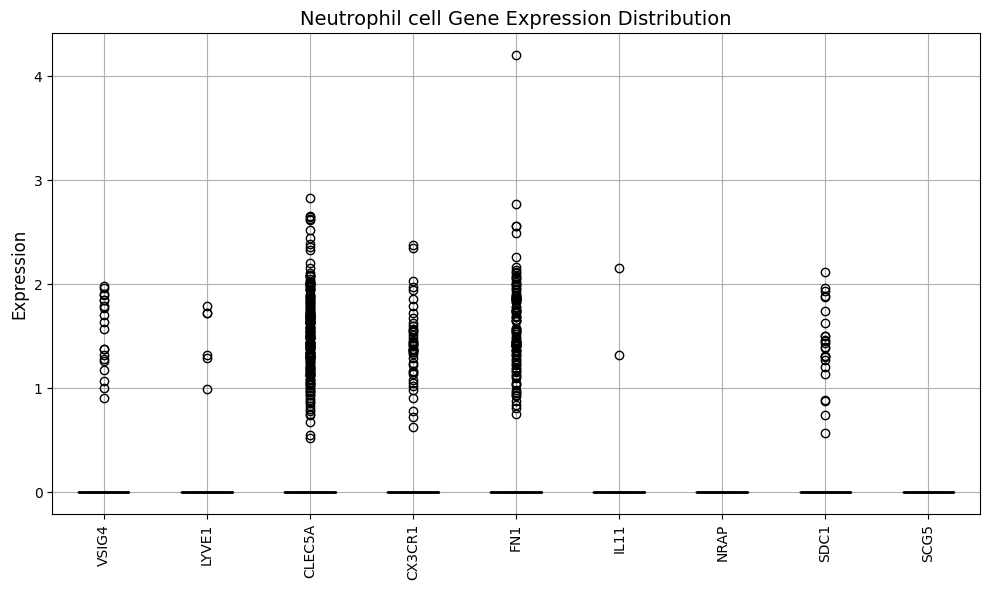

In [151]:
# 유전자별 발현 박스플롯 (검은색 박스/중앙선)
plt.figure(figsize=(10, 6))
ax = df.T.boxplot(
    vert=True,
    rot=90,
    boxprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markeredgecolor='black', markerfacecolor='none')
)
plt.title("Neutrophil cell Gene Expression Distribution", fontsize=14)
plt.ylabel("Expression", fontsize=12)
plt.tight_layout()
# # y축 범위 및 눈금 간격 설정
# plt.ylim(0, 1.75)
# plt.yticks(np.arange(0, 1.75 + 0.001, 0.25))
plt.show()

In [152]:
# 2. 메타데이터 로드
meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_neutrophil_consensus.csv"
meta = pd.read_csv(meta_path, index_col="cell_name")  
meta
# index: cell_name, 컬럼 중 'Group_born'에 MSI/MSS 정보가 들어 있어요

,Group_born,Batch,Group
cell_name,,,
Che_2021-SRR14710629-GGGATGAGTTGACGTT,MSS,Neutrophil,MSI_high
Chen_2024-GSM7558371-GCAAACTGTCAGTGGA,MSI,Neutrophil,MSI_high
Chen_2024-GSM7558464-GTCACGGCACAACGCC,MSI,Neutrophil,MSI_high
Chen_2024-GSM7558510-TGAGCCGGTTTGTTTC,MSI,Neutrophil,MSI_high
Chen_2024-GSM7558567-AAAGTAGCATGGATGG,MSI,Neutrophil,MSI_high
...,...,...,...
Wu_2022_CD45Pos-P19_Colon_T-TTGCATTTCCGAGAAG-1,MSS,Neutrophil,MSI_high
Wu_2022_CD45Pos-P14_Liver_T-ACAGGGAAGACATCCT-1,MSS,Neutrophil,MSI_high
Zheng_2022-GSM4904238-AAGGTTCAGTGGCACA,MSS,Neutrophil,MSI_high


In [153]:
# 2) 전체 셀 개수
total_cells = meta.shape[0]

# 3) MSI vs MSS 셀 개수
group_counts = meta["Group_born"].value_counts()

print(f"전체 셀 개수: {total_cells}")
print("Group_born별 셀 개수:")
print(group_counts)

전체 셀 개수: 12276
Group_born별 셀 개수:
Group_born
MSS    10611
MSI     1665
Name: count, dtype: int64


In [154]:
# 2) 그룹별 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 발현된 셀 개수 계산
expr_counts = pd.DataFrame({
    "msi_count":   (df[msi_cells] > 0).sum(axis=1),
    "mss_count":   (df[mss_cells] > 0).sum(axis=1)
})

# 4) 두 그룹 합 대비 비율 (각 유전자별)
expr_props = expr_counts.div(expr_counts.sum(axis=1), axis=0)
expr_props.columns = ["msi_probability", "mss_prbability"]
expr_props

,msi_probability,mss_prbability
VSIG4,0.150000,0.850000
LYVE1,0.000000,1.000000
CLEC5A,0.130208,0.869792
CX3CR1,0.711111,0.288889
FN1,0.100917,0.899083
IL11,0.500000,0.500000
NRAP,NaN,NaN
SDC1,0.083333,0.916667
SCG5,NaN,NaN


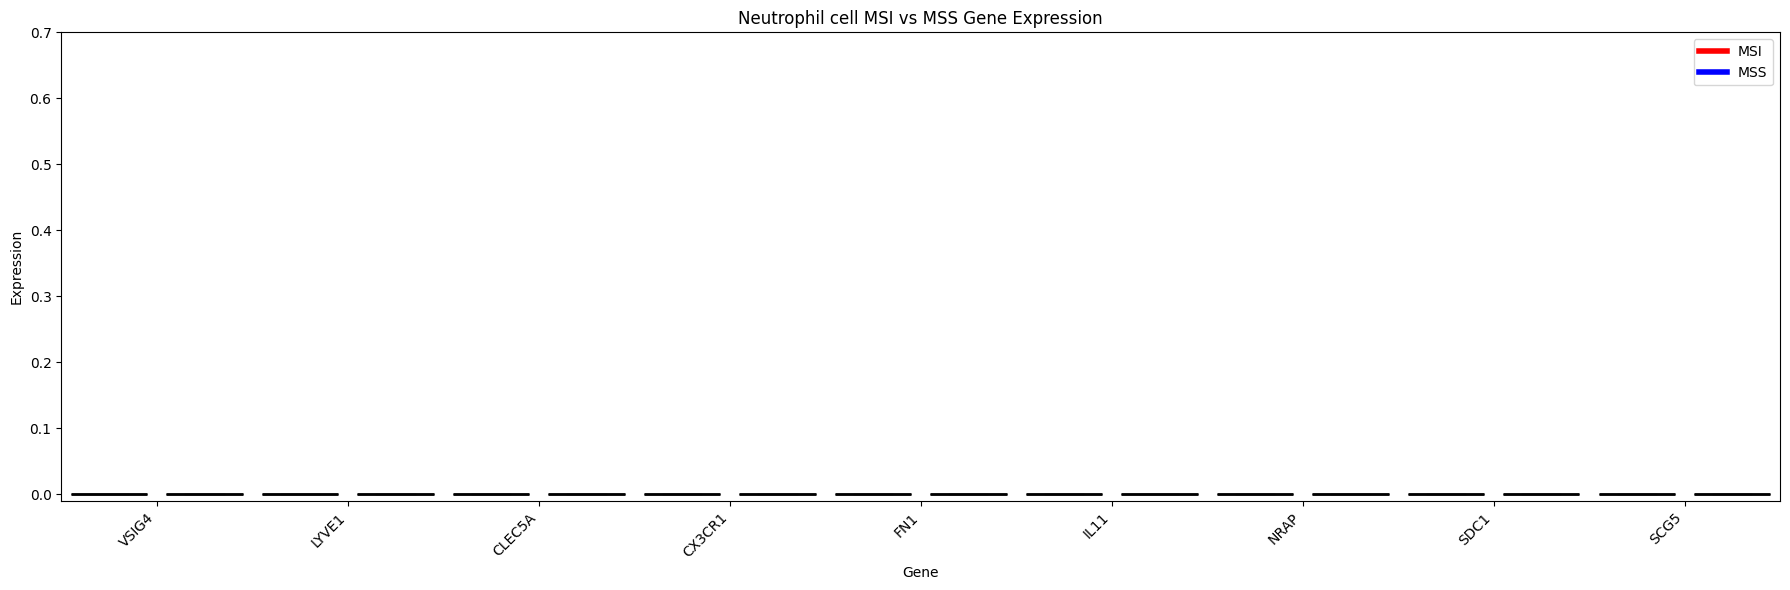

In [155]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 2) MSI/MSS 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 유전자 리스트 (인덱스)
genes = df.index.tolist()

# 4) 데이터와 위치 설정
data = []
positions = []
labels = []  # for gene names at center

for i, gene in enumerate(genes):
    # 각 gene마다 MSI 데이터, MSS 데이터 추가
    data.append(df.loc[gene, msi_cells].dropna())
    data.append(df.loc[gene, mss_cells].dropna())
    # 위치: 2*i+1, 2*i+2
    positions.extend([2*i+1, 2*i+2])
    # gene label 위치 중앙(2*i+1.5)
    labels.append((2*i+1 + 2*i+2)/2)

# 5) 박스플롯
# plt.figure(figsize=(2*len(genes), 6))
# box = plt.boxplot(data,
#                   positions=positions,
#                   widths=0.8,
#                   patch_artist=True,
#                   showfliers=False)
# 5) 박스플롯 그리기 (medianprops 추가)
plt.figure(figsize=(2*len(genes), 6))
box = plt.boxplot(
    data,
    positions=positions,
    widths=0.8,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)

# 6) 색상 지정: MSI 빨강, MSS 파랑
for idx, patch in enumerate(box['boxes']):
    if idx % 2 == 0:      # 짝수 인덱스 → MSI
        patch.set_facecolor('red')
    else:                 # 홀수 인덱스 → MSS
        patch.set_facecolor('blue')

# x축 눈금: gene 이름을 중앙에
plt.xticks(labels, genes, rotation=45, ha='right')

# 8) 범례 추가
red_patch = plt.Line2D([0], [0], color='red', lw=4)
blue_patch = plt.Line2D([0], [0], color='blue', lw=4)
plt.legend([red_patch, blue_patch], ['MSI', 'MSS'], loc='upper right')

plt.xlabel("Gene")
plt.ylabel("Expression")
plt.title("Neutrophil cell MSI vs MSS Gene Expression")
        
plt.ylim(-0.01, 0.7)
plt.tight_layout()
plt.show()

## Stromal

In [156]:
# 1. 데이터 로드
matrix_path = "/data/project/arpa_h/raw_data/split/9_genes_original/raw_stromal_filtered_matrix.csv"
df = pd.read_csv(matrix_path, index_col=0)  # Unnamed: 0 → gene names
#df

# 원하는 순서의 리스트
gene_order = ["VSIG4", "LYVE1", "CLEC5A", "CX3CR1", "FN1", "IL11", "NRAP", "SDC1", "SCG5"]
df = df.loc[gene_order]
df

,Che_2021-SRR14710630-AACCATGGTTTAGCTG,Che_2021-SRR14710630-AAGGTTCAGACCTTTG,Che_2021-SRR14710630-AAGGTTCTCGGCTACG,Che_2021-SRR14710630-ACTGAGTTCACCGTAA,Che_2021-SRR14710630-ACTGTCCAGCCACGCT,Che_2021-SRR14710630-AGAATAGTCTCTGAGA,Che_2021-SRR14710630-AGAGCTTGTGCAGACA,Che_2021-SRR14710630-AGCGGTCTCGGCGCAT,Che_2021-SRR14710630-AGCTTGACATCCCATC,Che_2021-SRR14710630-ATCATGGGTCTCCACT,...,Zheng_2022-GSM4904240-ACCTTTACATGTCCTC,Zheng_2022-GSM4904240-AGGTCCGTCTTAGCCC,Zheng_2022-GSM4904240-CATCAGATCTACCTGC,Zheng_2022-GSM4904240-GGATTACGTATGGTTC,Zheng_2022-GSM4904240-GTGGGTCAGAACAACT,Zheng_2022-GSM4904240-TCCACACTCACTCCTG,Zheng_2022-GSM4904240-TTTGCGCAGCTAGCCC,Zheng_2022-GSM4904241-CTCTAATTCCGAAGAG,Zheng_2022-GSM4904241-GAACGGAGTCATCGGC,Zheng_2022-GSM4904241-TCTTTCCGTAATTGGA
VSIG4,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
LYVE1,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
CLEC5A,0.000000,0.000000,0.000000,0.992796,0.000000,0.0,0.000000,0.00000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
CX3CR1,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
FN1,2.157984,2.416717,2.447539,1.481045,1.099523,0.0,1.970887,0.81978,2.472333,2.487461,...,2.22989,1.844384,2.592423,1.065516,2.511851,1.97973,2.613234,1.934125,1.707951,1.536022
IL11,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
NRAP,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
SDC1,0.493358,0.000000,0.000000,0.000000,0.000000,0.0,0.600816,0.00000,0.000000,0.477982,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
SCG5,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00000,0.000000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000


In [157]:
# Median 발현값
median_expr = df.median(axis=1, skipna=True)
median_expr

VSIG4     0.000000
LYVE1     0.000000
CLEC5A    0.000000
CX3CR1    0.000000
FN1       0.610251
IL11      0.000000
NRAP      0.000000
SDC1      0.000000
SCG5      0.000000
dtype: float64

In [158]:
# mean 발현값
mean_expr = df.mean(axis=1, skipna=True)
print(mean_expr)
formatted_mean_expr = mean_expr.apply(lambda x: f"{x:.2e}")
print(formatted_mean_expr)

VSIG4     0.000323
LYVE1     0.017264
CLEC5A    0.000262
CX3CR1    0.000387
FN1       0.848880
IL11      0.024163
NRAP      0.000092
SDC1      0.014996
SCG5      0.014308
dtype: float64
VSIG4     3.23e-04
LYVE1     1.73e-02
CLEC5A    2.62e-04
CX3CR1    3.87e-04
FN1       8.49e-01
IL11      2.42e-02
NRAP      9.15e-05
SDC1      1.50e-02
SCG5      1.43e-02
dtype: object


In [159]:
# NaN을 0으로 치지 않고, 실제 0인 셀만 세기
zero_only = (df == 0)
zero_ratio = zero_only.sum(axis=1) / df.shape[1]
print(zero_ratio)

VSIG4     0.999268
LYVE1     0.963252
CLEC5A    0.999366
CX3CR1    0.999073
FN1       0.386476
IL11      0.970275
NRAP      0.999756
SDC1      0.964910
SCG5      0.961594
dtype: float64


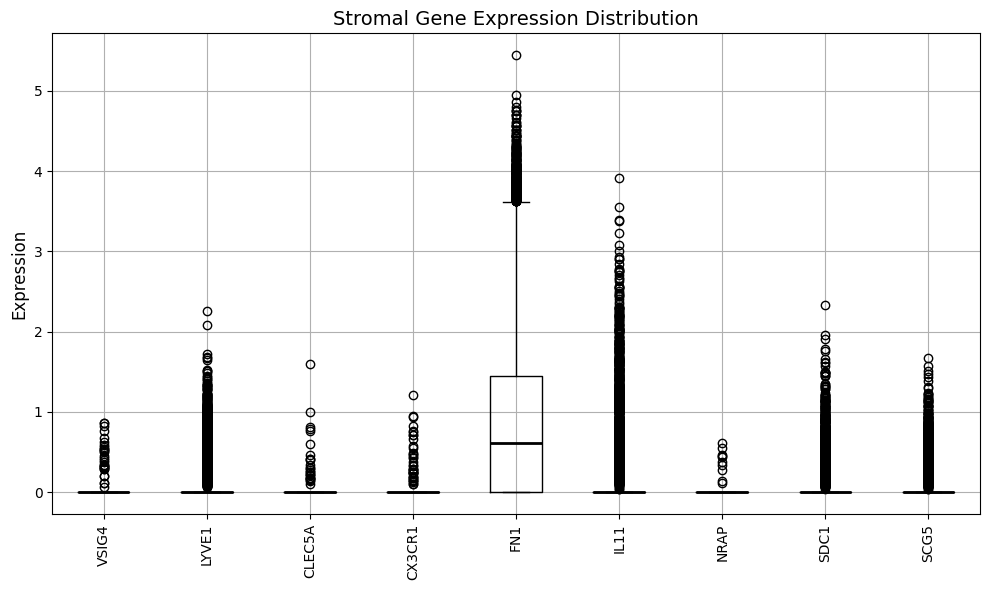

In [160]:
# 유전자별 발현 박스플롯 (검은색 박스/중앙선)
plt.figure(figsize=(10, 6))
ax = df.T.boxplot(
    vert=True,
    rot=90,
    boxprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markeredgecolor='black', markerfacecolor='none')
)
plt.title("Stromal Gene Expression Distribution", fontsize=14)
plt.ylabel("Expression", fontsize=12)
plt.tight_layout()
plt.show()

In [161]:
# 2. 메타데이터 로드
meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_stromal_consensus.csv"
meta = pd.read_csv(meta_path, index_col="cell_name")  
meta
# index: cell_name, 컬럼 중 'Group_born'에 MSI/MSS 정보가 들어 있어요

,Group_born,Batch,Group
cell_name,,,
Che_2021-SRR14710630-AACCATGGTTTAGCTG,MSS,Stromal cell,MSS_high
Che_2021-SRR14710630-AAGGTTCAGACCTTTG,MSS,Stromal cell,MSS_high
Che_2021-SRR14710630-AAGGTTCTCGGCTACG,MSS,Stromal cell,MSS_high
Che_2021-SRR14710630-ACTGAGTTCACCGTAA,MSS,Stromal cell,MSS_high
Che_2021-SRR14710630-ACTGTCCAGCCACGCT,MSS,Stromal cell,MSS_high
...,...,...,...
Zheng_2022-GSM4904240-TCCACACTCACTCCTG,MSS,Stromal cell,MSI_high
Zheng_2022-GSM4904240-TTTGCGCAGCTAGCCC,MSS,Stromal cell,MSI_high
Zheng_2022-GSM4904241-CTCTAATTCCGAAGAG,MSS,Stromal cell,MSI_high


In [162]:
# 2) 전체 셀 개수
total_cells = meta.shape[0]

# 3) MSI vs MSS 셀 개수
group_counts = meta["Group_born"].value_counts()

print(f"전체 셀 개수: {total_cells}")
print("Group_born별 셀 개수:")
print(group_counts)

전체 셀 개수: 41009
Group_born별 셀 개수:
Group_born
MSS    26205
MSI    14804
Name: count, dtype: int64


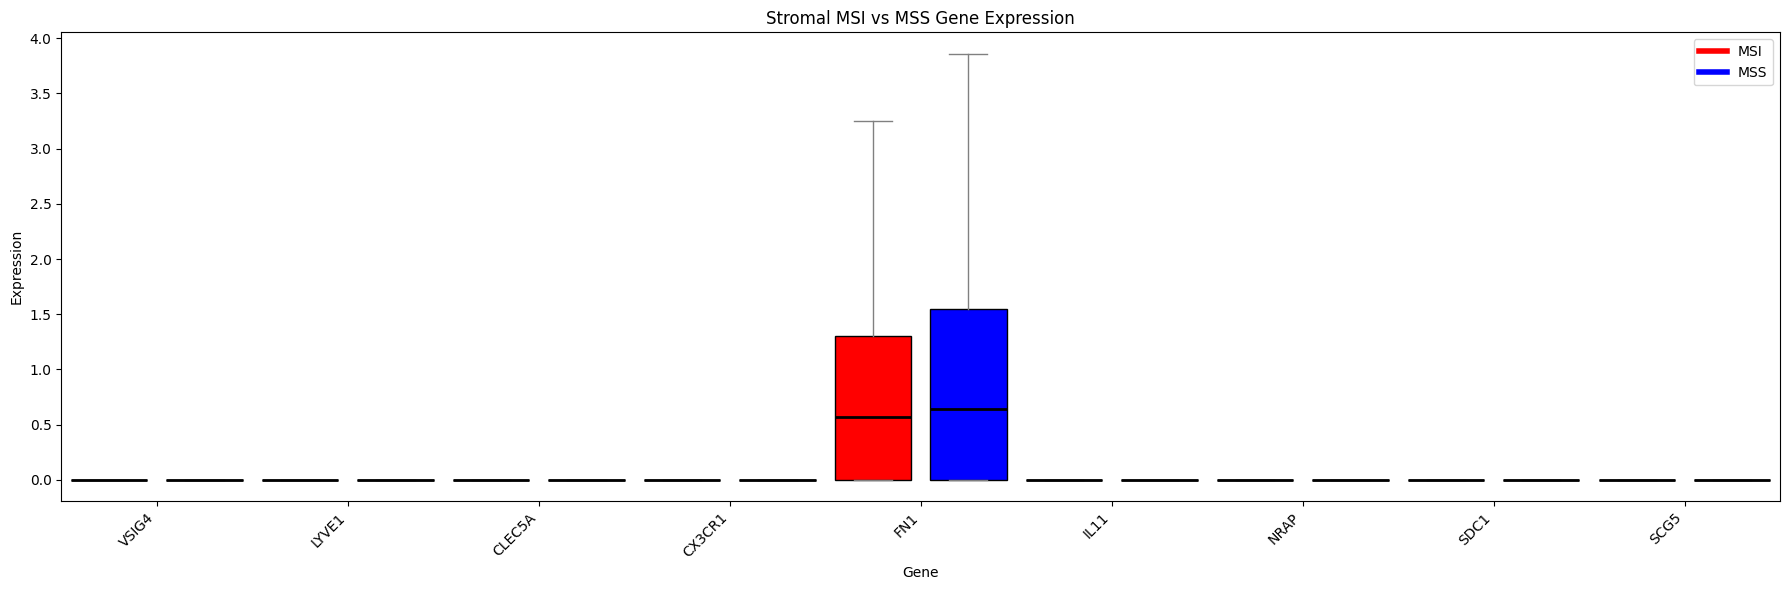

In [163]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 2) MSI/MSS 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 유전자 리스트 (인덱스)
genes = df.index.tolist()

# 4) 데이터와 위치 설정
data = []
positions = []
labels = []  # for gene names at center

for i, gene in enumerate(genes):
    # 각 gene마다 MSI 데이터, MSS 데이터 추가
    data.append(df.loc[gene, msi_cells].dropna())
    data.append(df.loc[gene, mss_cells].dropna())
    # 위치: 2*i+1, 2*i+2
    positions.extend([2*i+1, 2*i+2])
    # gene label 위치 중앙(2*i+1.5)
    labels.append((2*i+1 + 2*i+2)/2)

# 5) 박스플롯
# plt.figure(figsize=(2*len(genes), 6))
# box = plt.boxplot(data,
#                   positions=positions,
#                   widths=0.8,
#                   patch_artist=True,
#                   showfliers=False)
# 5) 박스플롯 그리기 (medianprops 추가)
plt.figure(figsize=(2*len(genes), 6))
box = plt.boxplot(
    data,
    positions=positions,
    widths=0.8,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)

# 6) 색상 지정: MSI 빨강, MSS 파랑
for idx, patch in enumerate(box['boxes']):
    if idx % 2 == 0:      # 짝수 인덱스 → MSI
        patch.set_facecolor('red')
    else:                 # 홀수 인덱스 → MSS
        patch.set_facecolor('blue')

# x축 눈금: gene 이름을 중앙에
plt.xticks(labels, genes, rotation=45, ha='right')

# 8) 범례 추가
red_patch = plt.Line2D([0], [0], color='red', lw=4)
blue_patch = plt.Line2D([0], [0], color='blue', lw=4)
plt.legend([red_patch, blue_patch], ['MSI', 'MSS'], loc='upper right')

plt.xlabel("Gene")
plt.ylabel("Expression")
plt.title("Stromal MSI vs MSS Gene Expression")
        

plt.tight_layout()
plt.show()

## Mast

In [80]:
# 1. 데이터 로드
matrix_path = "/data/project/arpa_h/raw_data/split/9_genes_original/raw_Mast_cell_filtered_matrix.csv"
df = pd.read_csv(matrix_path, index_col=0)  # Unnamed: 0 → gene names
#df

# 원하는 순서의 리스트
gene_order = ["VSIG4", "LYVE1", "CLEC5A", "CX3CR1", "FN1", "IL11", "NRAP", "SDC1", "SCG5"]
df = df.loc[gene_order]
df

,Che_2021-SRR14710623-GCAAACTTCACGCATA,Che_2021-SRR14710620-ACACCGGAGGATGGTC,Che_2021-SRR14710620-AGCATACCAGTATGCT,Che_2021-SRR14710620-AGCGTCGGTGACTACT,Che_2021-SRR14710620-CAAGAAATCCTTCAAT,Che_2021-SRR14710620-CGCCAAGAGATCGGGT,Che_2021-SRR14710620-CGTCAGGGTACTTCTT,Che_2021-SRR14710620-CTACATTGTAGCGTCC,Che_2021-SRR14710620-CTGCTGTAGCCTTGAT,Che_2021-SRR14710620-GCTGCTTAGTGATCGG,...,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L31-CGTGTAACAACACCCG,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L31-CGTTAGAGTGCACTTA,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L31-CGTTCTGAGCTCTCGG,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L31-CTACCCAAGTCTCGGC,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L31-GATCAGTAGAGCCTAG,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L31-GGCTCGAAGCGATCCC,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L31-TTAGGCACACCTCGGA,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L32-CGGAGTCTCATGTCTT,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L32-GACTGCGAGTTAGGTA,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L32-TCGCGTTTCCTAGAAC
VSIG4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
LYVE1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CLEC5A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CX3CR1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
FN1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
IL11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NRAP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SDC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SCG5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [81]:
# Median 발현값
median_expr = df.median(axis=1, skipna=True)
median_expr

VSIG4     0.0
LYVE1     0.0
CLEC5A    0.0
CX3CR1    0.0
FN1       0.0
IL11      0.0
NRAP      0.0
SDC1      0.0
SCG5      0.0
dtype: float64

In [82]:
# mean 발현값
mean_expr = df.mean(axis=1, skipna=True)
print(mean_expr)
formatted_mean_expr = mean_expr.apply(lambda x: f"{x:.2e}")
print(formatted_mean_expr)

VSIG4     0.001162
LYVE1     0.000252
CLEC5A    0.000406
CX3CR1    0.000000
FN1       0.014508
IL11      0.001866
NRAP      0.000000
SDC1      0.005027
SCG5      0.002671
dtype: float64
VSIG4     1.16e-03
LYVE1     2.52e-04
CLEC5A    4.06e-04
CX3CR1    0.00e+00
FN1       1.45e-02
IL11      1.87e-03
NRAP      0.00e+00
SDC1      5.03e-03
SCG5      2.67e-03
dtype: object


In [83]:
# NaN을 0으로 치지 않고, 실제 0인 셀만 세기
zero_only = (df == 0)
zero_ratio = zero_only.sum(axis=1) / df.shape[1]
print(zero_ratio)

VSIG4     0.998380
LYVE1     0.999676
CLEC5A    0.999676
CX3CR1    1.000000
FN1       0.985742
IL11      0.998056
NRAP      1.000000
SDC1      0.994491
SCG5      0.996111
dtype: float64


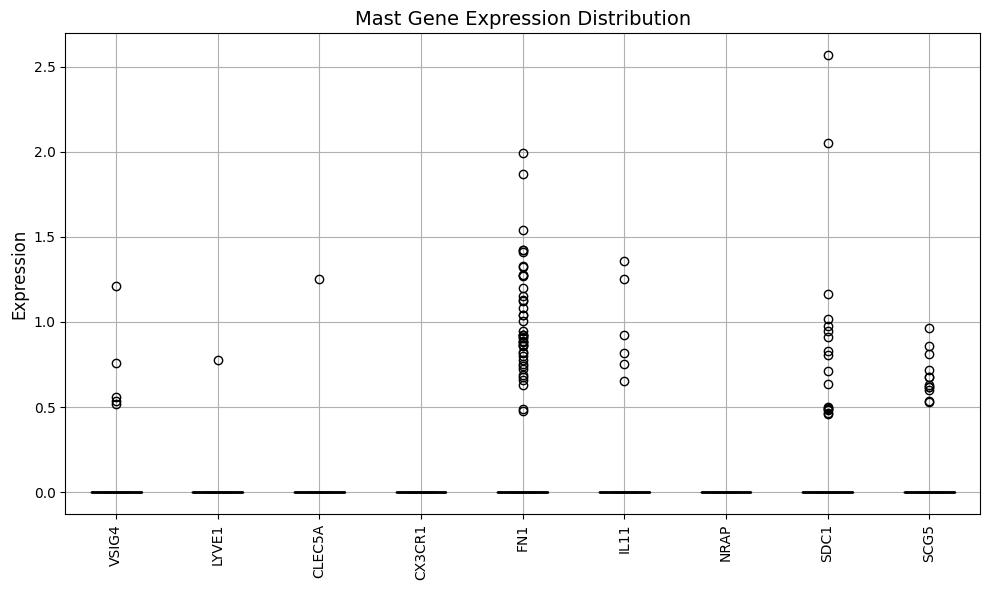

In [84]:
# 유전자별 발현 박스플롯 (검은색 박스/중앙선)
plt.figure(figsize=(10, 6))
ax = df.T.boxplot(
    vert=True,
    rot=90,
    boxprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markeredgecolor='black', markerfacecolor='none')
)
plt.title("Mast Gene Expression Distribution", fontsize=14)
plt.ylabel("Expression", fontsize=12)
plt.tight_layout()
# plt.ylim(-0.01, 1.75)
# plt.yticks(np.arange(0, 1.75 + 0.001, 0.25))
plt.show()

In [85]:
# 2. 메타데이터 로드
meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_mast_cell_consensus.csv"
meta = pd.read_csv(meta_path, index_col="cell_name")  
meta
# index: cell_name, 컬럼 중 'Group_born'에 MSI/MSS 정보가 들어 있어요

,Group_born,Batch,Group
cell_name,,,
Che_2021-SRR14710623-GCAAACTTCACGCATA,MSS,Mast cell,MSS_high
Che_2021-SRR14710620-ACACCGGAGGATGGTC,MSS,Mast cell,MSS_high
Che_2021-SRR14710620-AGCATACCAGTATGCT,MSS,Mast cell,MSS_high
Che_2021-SRR14710620-AGCGTCGGTGACTACT,MSS,Mast cell,MSS_high
Che_2021-SRR14710620-CAAGAAATCCTTCAAT,MSS,Mast cell,MSS_high
...,...,...,...
Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L31-GGCTCGAAGCGATCCC,MSS,Mast cell,MSS_high
Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L31-TTAGGCACACCTCGGA,MSS,Mast cell,MSS_high
Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L32-CGGAGTCTCATGTCTT,MSS,Mast cell,MSS_high


In [86]:
# 2) 전체 셀 개수
total_cells = meta.shape[0]

# 3) MSI vs MSS 셀 개수
group_counts = meta["Group_born"].value_counts()

print(f"전체 셀 개수: {total_cells}")
print("Group_born별 셀 개수:")
print(group_counts)

전체 셀 개수: 3086
Group_born별 셀 개수:
Group_born
MSS    2261
MSI     825
Name: count, dtype: int64


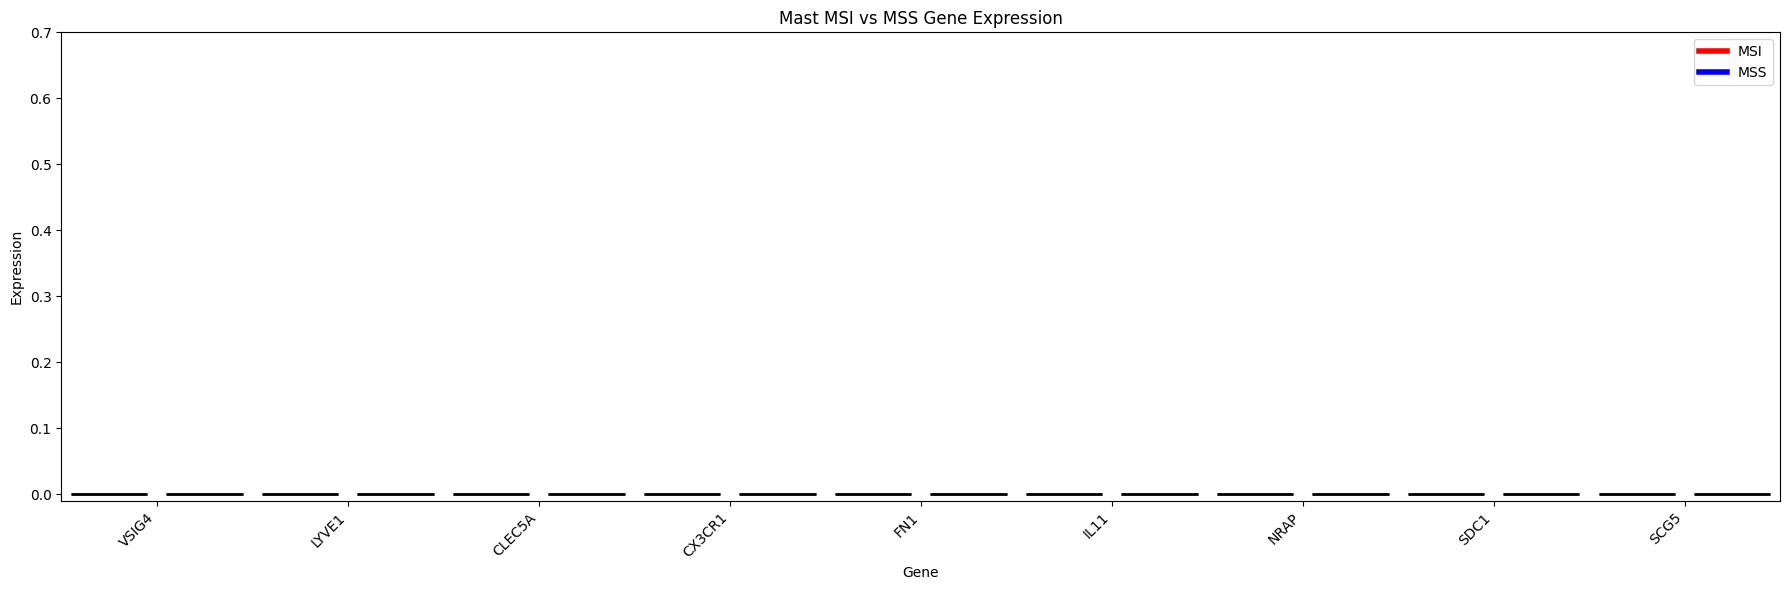

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 2) MSI/MSS 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 유전자 리스트 (인덱스)
genes = df.index.tolist()

# 4) 데이터와 위치 설정
data = []
positions = []
labels = []  # for gene names at center

for i, gene in enumerate(genes):
    # 각 gene마다 MSI 데이터, MSS 데이터 추가
    data.append(df.loc[gene, msi_cells].dropna())
    data.append(df.loc[gene, mss_cells].dropna())
    # 위치: 2*i+1, 2*i+2
    positions.extend([2*i+1, 2*i+2])
    # gene label 위치 중앙(2*i+1.5)
    labels.append((2*i+1 + 2*i+2)/2)

# 5) 박스플롯
# plt.figure(figsize=(2*len(genes), 6))
# box = plt.boxplot(data,
#                   positions=positions,
#                   widths=0.8,
#                   patch_artist=True,
#                   showfliers=False)
# 5) 박스플롯 그리기 (medianprops 추가)
plt.figure(figsize=(2*len(genes), 6))
box = plt.boxplot(
    data,
    positions=positions,
    widths=0.8,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)

# 6) 색상 지정: MSI 빨강, MSS 파랑
for idx, patch in enumerate(box['boxes']):
    if idx % 2 == 0:      # 짝수 인덱스 → MSI
        patch.set_facecolor('red')
    else:                 # 홀수 인덱스 → MSS
        patch.set_facecolor('blue')

# x축 눈금: gene 이름을 중앙에
plt.xticks(labels, genes, rotation=45, ha='right')

# 8) 범례 추가
red_patch = plt.Line2D([0], [0], color='red', lw=4)
blue_patch = plt.Line2D([0], [0], color='blue', lw=4)
plt.legend([red_patch, blue_patch], ['MSI', 'MSS'], loc='upper right')

plt.xlabel("Gene")
plt.ylabel("Expression")
plt.title("Mast MSI vs MSS Gene Expression")
        
plt.ylim(-0.01, 0.7)
plt.tight_layout()
plt.show()

## Plasma

In [164]:
# 1. 데이터 로드
matrix_path = "/data/project/arpa_h/raw_data/split/9_genes_original/raw_plasma_filtered_matrix.csv"
df = pd.read_csv(matrix_path, index_col=0)  # Unnamed: 0 → gene names
#df

# 원하는 순서의 리스트
gene_order = ["VSIG4", "LYVE1", "CLEC5A", "CX3CR1", "FN1", "IL11", "NRAP", "SDC1", "SCG5"]
df = df.loc[gene_order]
df

,Borras_2023_KUL5_CD45Pos-EXT099-CATCGAAAGACAGAGA,Borras_2023_SMC5-SMC200T-GGACAGACACCACGTG,Borras_2023_SMC5-SMC234T-GTACTCCGTCCAGTAT,Che_2021-SRR14710630-TTTGGTTCACGGTAAG,Che_2021-SRR14710629-AAAGATGGTTTGACTG,Che_2021-SRR14710629-AATCGGTCAATGGATA,Che_2021-SRR14710629-ACGAGGAAGATCCCGC,Che_2021-SRR14710629-ACGAGGATCAAGGCTT,Che_2021-SRR14710629-ACGGGCTTCAGCACAT,Che_2021-SRR14710629-ACTATCTCACTGAAGG,...,Zheng_2022-GSM4904236-GCTGGGTGTCTAAAGA,Zheng_2022-GSM4904236-GGGTCTGGTTGGGACA,Zheng_2022-GSM4904237-CCATTCGGTTCGCGAC,Zheng_2022-GSM4904237-CGTTAGAAGAGTGACC,Zheng_2022-GSM4904239-CCTTCGACAGACAGGT,Zheng_2022-GSM4904239-TCTATTGGTAGCAAAT,Zheng_2022-GSM4904239-TGGTTAGTCTAACCGA,Zheng_2022-GSM4904240-AACCGCGTCCGTAGTA,Zheng_2022-GSM4904242-CAACTAGGTCACCTAA,Zheng_2022-GSM4904245-TGACTTTTCAGTTTGG
VSIG4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0
LYVE1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0
CLEC5A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0
CX3CR1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0
FN1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0
IL11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0
NRAP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0
SDC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.854623,1.158967,0.0,1.087606,0.0,0.0,0.234308,0.0
SCG5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0


In [165]:
# Median 발현값
median_expr = df.median(axis=1, skipna=True)
median_expr

VSIG4     0.0
LYVE1     0.0
CLEC5A    0.0
CX3CR1    0.0
FN1       0.0
IL11      0.0
NRAP      0.0
SDC1      0.0
SCG5      0.0
dtype: float64

In [166]:
# mean 발현값
mean_expr = df.mean(axis=1, skipna=True)
print(mean_expr)
formatted_mean_expr = mean_expr.apply(lambda x: f"{x:.2e}")
print(formatted_mean_expr)

VSIG4     0.000108
LYVE1     0.000235
CLEC5A    0.000259
CX3CR1    0.000100
FN1       0.010466
IL11      0.000438
NRAP      0.000063
SDC1      0.293578
SCG5      0.000541
dtype: float64
VSIG4     1.08e-04
LYVE1     2.35e-04
CLEC5A    2.59e-04
CX3CR1    1.00e-04
FN1       1.05e-02
IL11      4.38e-04
NRAP      6.30e-05
SDC1      2.94e-01
SCG5      5.41e-04
dtype: object


In [167]:
# NaN을 0으로 치지 않고, 실제 0인 셀만 세기
zero_only = (df == 0)
zero_ratio = zero_only.sum(axis=1) / df.shape[1]
print(zero_ratio)

VSIG4     0.999778
LYVE1     0.999728
CLEC5A    0.999679
CX3CR1    0.999580
FN1       0.988374
IL11      0.999161
NRAP      0.999901
SDC1      0.684414
SCG5      0.999210
dtype: float64


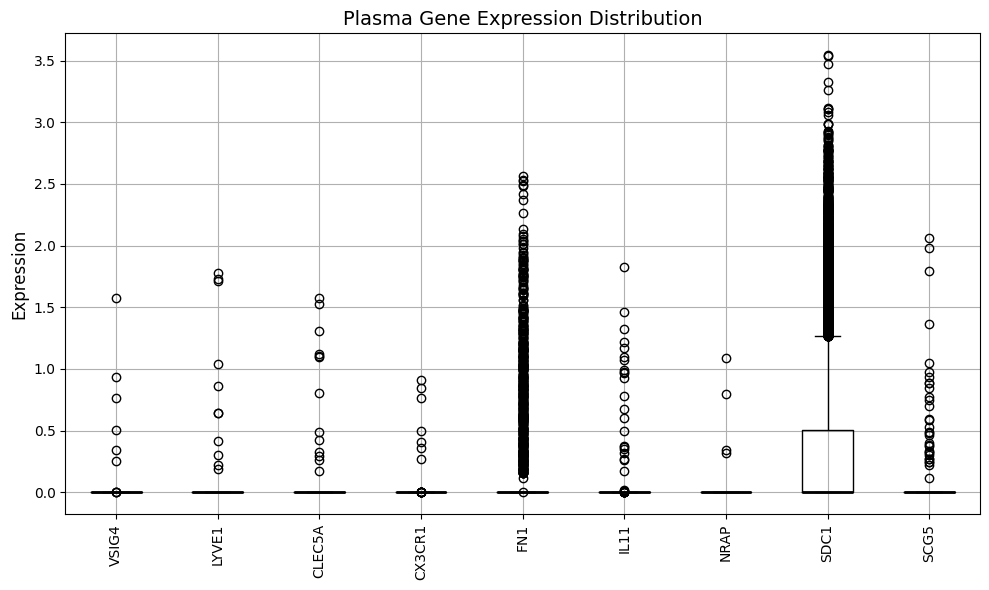

In [168]:
# 유전자별 발현 박스플롯 (검은색 박스/중앙선)
plt.figure(figsize=(10, 6))
ax = df.T.boxplot(
    vert=True,
    rot=90,
    boxprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markeredgecolor='black', markerfacecolor='none')
)
plt.title("Plasma Gene Expression Distribution", fontsize=14)
plt.ylabel("Expression", fontsize=12)
plt.tight_layout()

plt.show()

In [169]:
# 2. 메타데이터 로드
meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_Plasma_cell_consensus.csv"
meta = pd.read_csv(meta_path, index_col="cell_name")  
meta
# index: cell_name, 컬럼 중 'Group_born'에 MSI/MSS 정보가 들어 있어요

,Group_born,Batch,Group
cell_name,,,
Borras_2023_KUL5_CD45Pos-EXT099-CATCGAAAGACAGAGA,MSS,Plasma cell,MSI_high
Borras_2023_SMC5-SMC200T-GGACAGACACCACGTG,MSI,Plasma cell,MSI_high
Borras_2023_SMC5-SMC234T-GTACTCCGTCCAGTAT,MSI,Plasma cell,MSI_high
Che_2021-SRR14710630-TTTGGTTCACGGTAAG,MSS,Plasma cell,MSS_high
Che_2021-SRR14710629-AAAGATGGTTTGACTG,MSS,Plasma cell,MSS_high
...,...,...,...
Zheng_2022-GSM4904239-TCTATTGGTAGCAAAT,MSS,Plasma cell,MSI_high
Zheng_2022-GSM4904239-TGGTTAGTCTAACCGA,MSS,Plasma cell,MSI_high
Zheng_2022-GSM4904240-AACCGCGTCCGTAGTA,MSS,Plasma cell,MSI_high


In [170]:
# 2) 전체 셀 개수
total_cells = meta.shape[0]

# 3) MSI vs MSS 셀 개수
group_counts = meta["Group_born"].value_counts()

print(f"전체 셀 개수: {total_cells}")
print("Group_born별 셀 개수:")
print(group_counts)

전체 셀 개수: 40512
Group_born별 셀 개수:
Group_born
MSS    32566
MSI     7946
Name: count, dtype: int64


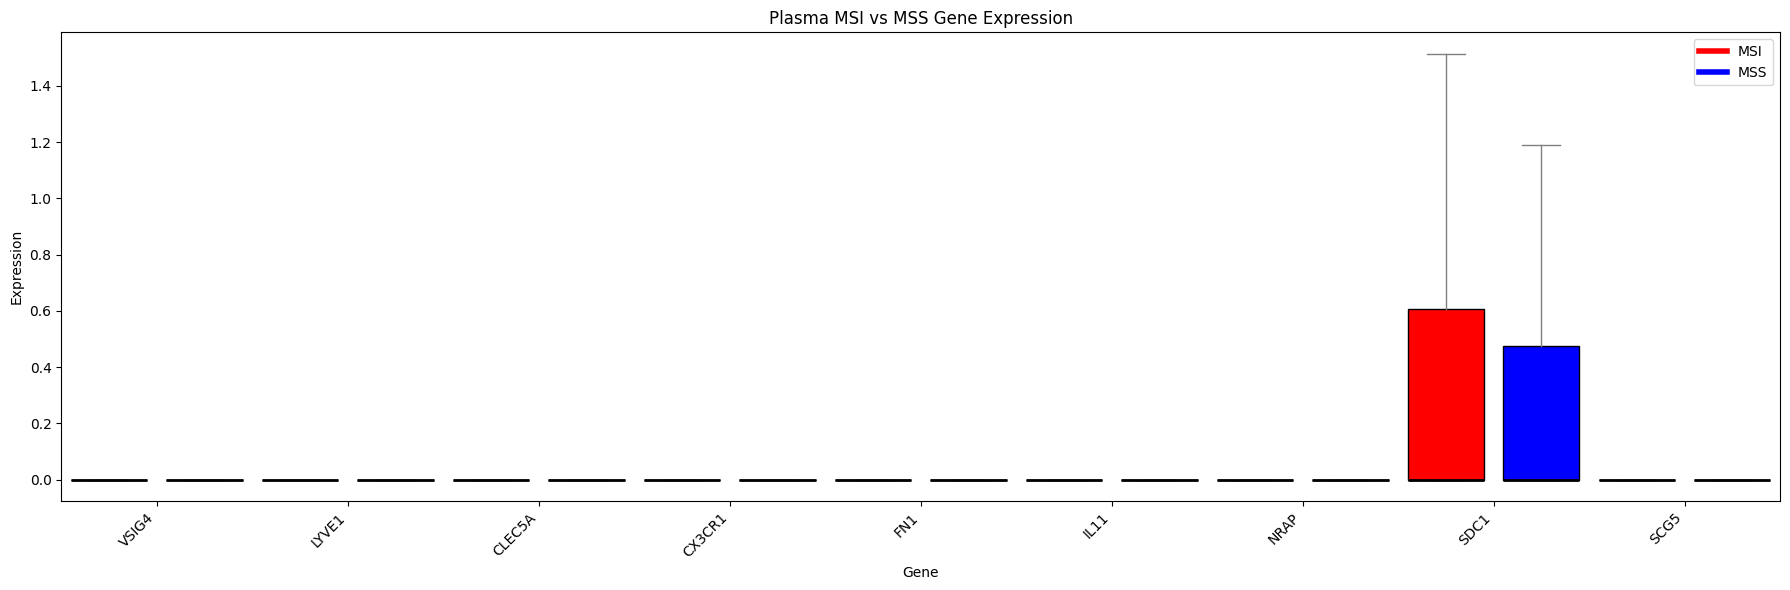

In [171]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 2) MSI/MSS 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 유전자 리스트 (인덱스)
genes = df.index.tolist()

# 4) 데이터와 위치 설정
data = []
positions = []
labels = []  # for gene names at center

for i, gene in enumerate(genes):
    # 각 gene마다 MSI 데이터, MSS 데이터 추가
    data.append(df.loc[gene, msi_cells].dropna())
    data.append(df.loc[gene, mss_cells].dropna())
    # 위치: 2*i+1, 2*i+2
    positions.extend([2*i+1, 2*i+2])
    # gene label 위치 중앙(2*i+1.5)
    labels.append((2*i+1 + 2*i+2)/2)

# 5) 박스플롯
# plt.figure(figsize=(2*len(genes), 6))
# box = plt.boxplot(data,
#                   positions=positions,
#                   widths=0.8,
#                   patch_artist=True,
#                   showfliers=False)
# 5) 박스플롯 그리기 (medianprops 추가)
plt.figure(figsize=(2*len(genes), 6))
box = plt.boxplot(
    data,
    positions=positions,
    widths=0.8,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)

# 6) 색상 지정: MSI 빨강, MSS 파랑
for idx, patch in enumerate(box['boxes']):
    if idx % 2 == 0:      # 짝수 인덱스 → MSI
        patch.set_facecolor('red')
    else:                 # 홀수 인덱스 → MSS
        patch.set_facecolor('blue')

# x축 눈금: gene 이름을 중앙에
plt.xticks(labels, genes, rotation=45, ha='right')

# 8) 범례 추가
red_patch = plt.Line2D([0], [0], color='red', lw=4)
blue_patch = plt.Line2D([0], [0], color='blue', lw=4)
plt.legend([red_patch, blue_patch], ['MSI', 'MSS'], loc='upper right')

plt.xlabel("Gene")
plt.ylabel("Expression")
plt.title("Plasma MSI vs MSS Gene Expression")
        

plt.tight_layout()
plt.show()

## B cell

In [112]:
# 1. 데이터 로드
matrix_path = "/data/project/arpa_h/raw_data/split/9_genes_original/raw_B_cell_filtered_matrix.csv"
df = pd.read_csv(matrix_path, index_col=0)  # Unnamed: 0 → gene names
#df

# 원하는 순서의 리스트
gene_order = ["VSIG4", "LYVE1", "CLEC5A", "CX3CR1", "FN1", "IL11", "NRAP", "SDC1", "SCG5"]
df = df.loc[gene_order]
df

,Borras_2023_SMC5-SMC145T-CACAGTAGTCAGCTAT,Che_2021-SRR14710630-AAACCTGGTTTGTTGG,Che_2021-SRR14710630-AAACGGGTCGCGTAGC,Che_2021-SRR14710630-AAAGATGGTCAAAGCG,Che_2021-SRR14710630-AACACGTCAGGGAGAG,Che_2021-SRR14710630-AACCGCGTCATAAAGG,Che_2021-SRR14710630-AACCGCGTCTGTTTGT,Che_2021-SRR14710630-AACTCTTCACGGACAA,Che_2021-SRR14710630-AACTCTTCATGAACCT,Che_2021-SRR14710630-AACTGGTGTGCGGTAA,...,Zheng_2022-GSM4904241-CGGAGTCAGTGGAGAA,Zheng_2022-GSM4904243-AAGTCTGAGCTAGTCT,Zheng_2022-GSM4904245-AAGGCAGCAGGTTTCA,Zheng_2022-GSM4904245-CCACGGACACACCGCA,Zheng_2022-GSM4904245-CGGCTAGCATAGTAAG,Zheng_2022-GSM4904245-GAAACTCAGGGAAACA,Zheng_2022-GSM4904245-GCCTCTAAGGCCGAAT,Zheng_2022-GSM4904245-TGGGCGTGTTGGTAAA,Zheng_2022-GSM4904245-TTGCCGTCATCCCATC,Zheng_2022-GSM4904246-GGGAATGCAGCGTTCG
VSIG4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
LYVE1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CLEC5A,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CX3CR1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
FN1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
IL11,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
NRAP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SDC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SCG5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [113]:
# Median 발현값
median_expr = df.median(axis=1, skipna=True)
median_expr

VSIG4     0.0
LYVE1     0.0
CLEC5A    0.0
CX3CR1    0.0
FN1       0.0
IL11      0.0
NRAP      0.0
SDC1      0.0
SCG5      0.0
dtype: float64

In [114]:
# mean 발현값
mean_expr = df.mean(axis=1, skipna=True)
print(mean_expr)
formatted_mean_expr = mean_expr.apply(lambda x: f"{x:.2e}")
print(formatted_mean_expr)

VSIG4     0.000610
LYVE1     0.000236
CLEC5A    0.000215
CX3CR1    0.001908
FN1       0.004877
IL11      0.000149
NRAP      0.000016
SDC1      0.003147
SCG5      0.000230
dtype: float64
VSIG4     6.10e-04
LYVE1     2.36e-04
CLEC5A    2.15e-04
CX3CR1    1.91e-03
FN1       4.88e-03
IL11      1.49e-04
NRAP      1.60e-05
SDC1      3.15e-03
SCG5      2.30e-04
dtype: object


In [115]:
# NaN을 0으로 치지 않고, 실제 0인 셀만 세기
zero_only = (df == 0)
zero_ratio = zero_only.sum(axis=1) / df.shape[1]
print(zero_ratio)

VSIG4     0.998936
LYVE1     0.999675
CLEC5A    0.999616
CX3CR1    0.997223
FN1       0.993086
IL11      0.999675
NRAP      0.999970
SDC1      0.995627
SCG5      0.999734
dtype: float64


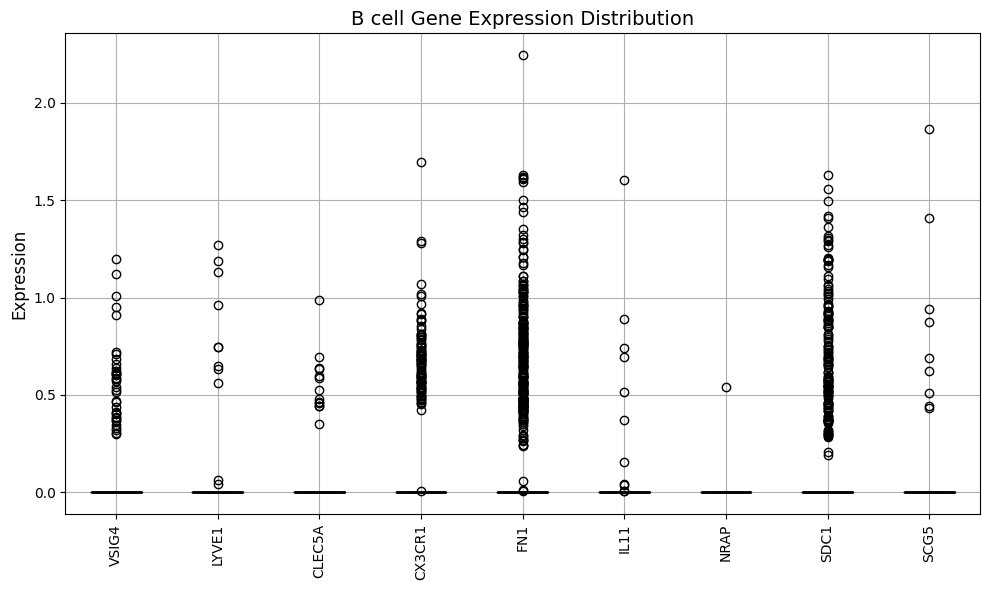

In [116]:
# 유전자별 발현 박스플롯 (검은색 박스/중앙선)
plt.figure(figsize=(10, 6))
ax = df.T.boxplot(
    vert=True,
    rot=90,
    boxprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markeredgecolor='black', markerfacecolor='none')
)
plt.title("B cell Gene Expression Distribution", fontsize=14)
plt.ylabel("Expression", fontsize=12)
plt.tight_layout()
# plt.ylim(-0.01, 1.75)
# plt.yticks(np.arange(0, 1.75 + 0.001, 0.25))
plt.show()

In [117]:
# 2. 메타데이터 로드
meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_B_cell_consensus.csv"
meta = pd.read_csv(meta_path, index_col="cell_name")  
meta
# index: cell_name, 컬럼 중 'Group_born'에 MSI/MSS 정보가 들어 있어요

,Group_born,Batch,Group
cell_name,,,
Borras_2023_SMC5-SMC145T-CACAGTAGTCAGCTAT,MSS,B cell,MSI_high
Che_2021-SRR14710630-AAACCTGGTTTGTTGG,MSS,B cell,MSS_high
Che_2021-SRR14710630-AAACGGGTCGCGTAGC,MSS,B cell,MSS_high
Che_2021-SRR14710630-AAAGATGGTCAAAGCG,MSS,B cell,MSS_high
Che_2021-SRR14710630-AACACGTCAGGGAGAG,MSS,B cell,MSS_high
...,...,...,...
Zheng_2022-GSM4904245-GAAACTCAGGGAAACA,MSS,B cell,MSS_high
Zheng_2022-GSM4904245-GCCTCTAAGGCCGAAT,MSS,B cell,MSS_high
Zheng_2022-GSM4904245-TGGGCGTGTTGGTAAA,MSS,B cell,MSS_high


In [118]:
# 2) 전체 셀 개수
total_cells = meta.shape[0]

# 3) MSI vs MSS 셀 개수
group_counts = meta["Group_born"].value_counts()

print(f"전체 셀 개수: {total_cells}")
print("Group_born별 셀 개수:")
print(group_counts)

전체 셀 개수: 33844
Group_born별 셀 개수:
Group_born
MSS    20405
MSI    13439
Name: count, dtype: int64


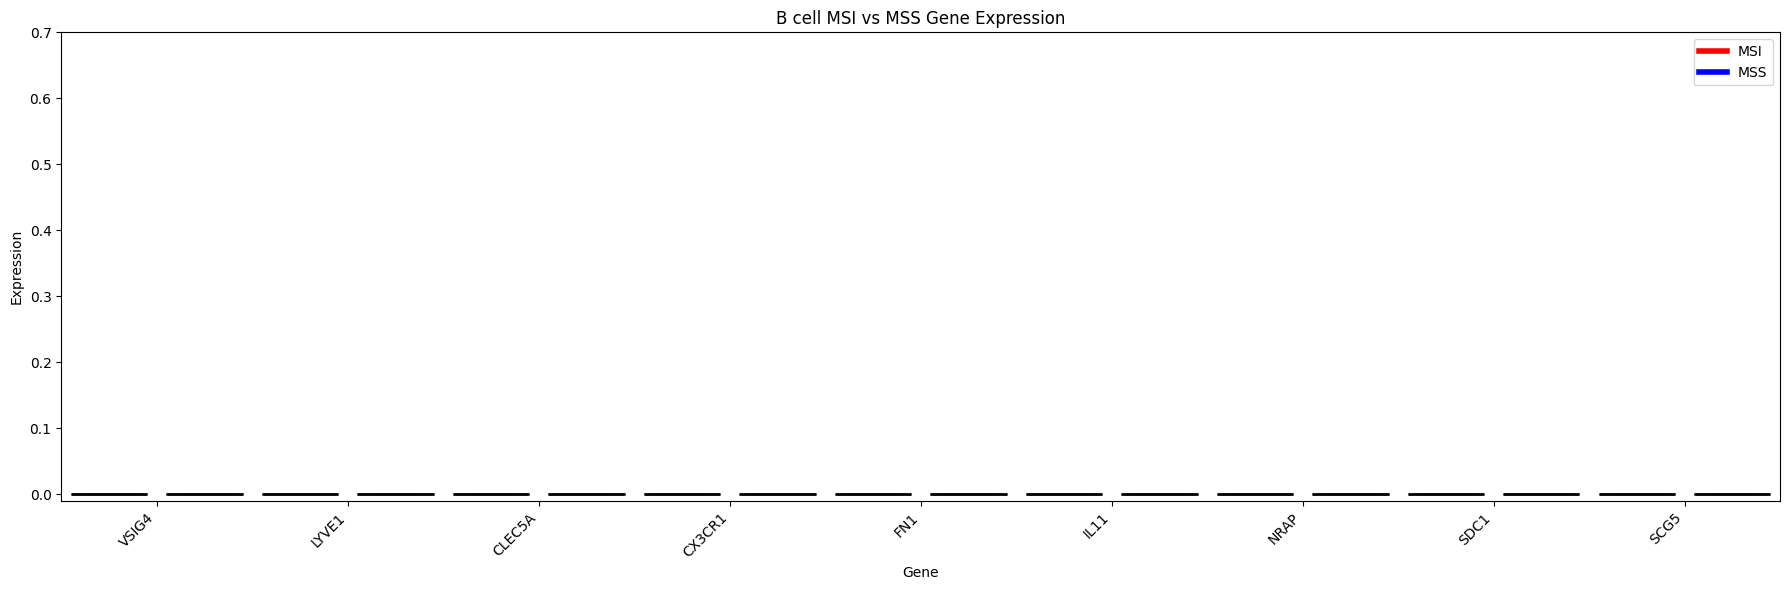

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 2) MSI/MSS 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 유전자 리스트 (인덱스)
genes = df.index.tolist()

# 4) 데이터와 위치 설정
data = []
positions = []
labels = []  # for gene names at center

for i, gene in enumerate(genes):
    # 각 gene마다 MSI 데이터, MSS 데이터 추가
    data.append(df.loc[gene, msi_cells].dropna())
    data.append(df.loc[gene, mss_cells].dropna())
    # 위치: 2*i+1, 2*i+2
    positions.extend([2*i+1, 2*i+2])
    # gene label 위치 중앙(2*i+1.5)
    labels.append((2*i+1 + 2*i+2)/2)

# 5) 박스플롯
# plt.figure(figsize=(2*len(genes), 6))
# box = plt.boxplot(data,
#                   positions=positions,
#                   widths=0.8,
#                   patch_artist=True,
#                   showfliers=False)
# 5) 박스플롯 그리기 (medianprops 추가)
plt.figure(figsize=(2*len(genes), 6))
box = plt.boxplot(
    data,
    positions=positions,
    widths=0.8,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)

# 6) 색상 지정: MSI 빨강, MSS 파랑
for idx, patch in enumerate(box['boxes']):
    if idx % 2 == 0:      # 짝수 인덱스 → MSI
        patch.set_facecolor('red')
    else:                 # 홀수 인덱스 → MSS
        patch.set_facecolor('blue')

# x축 눈금: gene 이름을 중앙에
plt.xticks(labels, genes, rotation=45, ha='right')

# 8) 범례 추가
red_patch = plt.Line2D([0], [0], color='red', lw=4)
blue_patch = plt.Line2D([0], [0], color='blue', lw=4)
plt.legend([red_patch, blue_patch], ['MSI', 'MSS'], loc='upper right')

plt.xlabel("Gene")
plt.ylabel("Expression")
plt.title("B cell MSI vs MSS Gene Expression")
        
plt.ylim(-0.01, 0.7)
plt.tight_layout()
plt.show()